# Notebook 06. Koreksi Objective Function f1, Screening Tuas Kebijakan, dan Penjalanan Ulang Optimisasi

Notebook ini adalah lanjutan Notebook 05. Ia dibuat karena pemeriksaan ulang
menemukan satu cacat pada definisi *objective function* (fungsi tujuan) pertama,
yaitu f1 inflasi pangan, yang membuat hasil optimisasi tidak dapat dibaca sebagaimana
tertulis. Notebook ini tidak menghapus Notebook 05. Ia memuat ulang mesin simulasi
Notebook 05 apa adanya, lalu memperbaiki definisi tujuan, menjalankan ulang pencarian,
dan menulis seluruh keluarannya ke folder terpisah bernama
Keluaran_Sumatranomics_2026_Sumut_NB06.

## Apa yang salah

Notebook 05 mendefinisikan f1 sebagai selisih antara dua rasio pertumbuhan:

    naik(x) = level harga pangan bulan terakhir / level harga pangan bulan pertama - 1
    f1(x)   = naik(x) - naik(baseline)

Seluruh tuas kebijakan bekerja sejak sublangkah pertama simulasi, sehingga penyebut
rasio tersebut, yaitu level harga pangan bulan pertama, ikut berubah ketika kebijakan
dijalankan. Akibatnya f1 mencampur dua hal yang berbeda, yaitu pengaruh kebijakan pada
level harga akhir dan pergeseran periode dasar. Bagian 2 membuktikan pencampuran itu
secara aljabar dan secara numerik.

## Apa yang dikerjakan notebook ini

1. Memuat ulang mesin simulasi tujuh blok dan seluruh koreksi struktural Notebook 05.
2. Menguraikan f1 lama menjadi dua komponen secara eksak, lalu melaporkan besarnya.
3. Melakukan *screening* (penyaringan) tuas kebijakan satu per satu untuk mengetahui
   tujuan mana yang benar benar dapat digerakkan oleh tuas mana.
4. Mendefinisikan ulang tujuan sebagai selisih *level* terhadap *baseline* pada akhir
   horizon, bukan selisih laju pertumbuhan.
5. Menjalankan ulang NSGA-III pada dua himpunan tujuan, yaitu himpunan asli agar hasil
   tetap dapat dibandingkan dengan Notebook 05, dan himpunan revisi yang menggantikan
   tujuan redundan dengan dua besaran sisi pasokan.
6. Mengulang propagasi ketidakpastian, *minimax regret*, diagnostik *discriminability*
   (keterbedaan sinyal terhadap derau parameter), dan diagnostik redundansi.
7. Menulis tabel, gambar, ringkasan naratif otomatis, dan manifes keluaran.

## Cara menjalankan

Letakkan notebook ini pada folder yang sama dengan Notebook 01 sampai 05 dan dengan
folder keluaran Keluaran_Sumatranomics_2026_Sumut sampai _NB04. Notebook 05 harus sudah
pernah dijalankan penuh sekali. Jalankan notebook ini dengan menu Run lalu Run All Cells.
Waktu penjalanan penuh sekitar tiga puluh sampai empat puluh menit pada mesin biasa.
Untuk uji coba cepat, setel MODE_CEPAT_NB06 menjadi True pada sel berikut.

In [1]:
# Sel 1.1 - Panel kendali dan pemuatan ulang mesin Notebook 05

# ===========================================================================
# PANEL KENDALI NOTEBOOK 06. Satu satunya tempat yang perlu diubah.
# ===========================================================================
MODE_CEPAT_NB06 = False      # True untuk uji coba cepat, hasilnya tidak boleh dikutip

# Himpunan tujuan yang dijalankan. "asli" memakai enam tujuan Notebook 05 dengan f1
# yang sudah diperbaiki, dipakai sebagai pembanding. "revisi" mengganti tujuan yang
# terbukti redundan dengan dua besaran sisi pasokan.
V6_SET_DIJALANKAN = ["revisi", "asli"]
V6_SET_UTAMA = "revisi"
# ===========================================================================

import json, re, io, contextlib, time, sys
from pathlib import Path

V6_POLA_NB05 = ["*05_Optimisasi_Kebijakan*.ipynb", "*Optimisasi_Kebijakan*.ipynb",
                "*05*Dashboard*Sumut*.ipynb"]


def v6_cari_notebook(daftar_pola):
    """Cari berkas Notebook 05 sampai tiga tingkat folder ke atas."""
    akar = Path.cwd().resolve()
    basis = []
    for _ in range(4):
        basis.append(akar)
        if akar.parent == akar:
            break
        akar = akar.parent
    calon = []
    for b in basis:
        for pola in daftar_pola:
            calon += [p for p in b.glob(pola) if p.is_file()]
            calon += [p for p in b.glob("*/" + pola) if p.is_file()]
    calon = sorted(set(calon), key=lambda p: (len(str(p)), str(p)))
    return calon[0] if calon else None


V6_JALUR_NB05 = v6_cari_notebook(V6_POLA_NB05)
if V6_JALUR_NB05 is None:
    raise FileNotFoundError(
        "Berkas Notebook 05 tidak ditemukan. Letakkan notebook ini pada folder yang "
        "sama dengan 05_Optimisasi_Kebijakan_dan_Dashboard_Sumut.ipynb.")

V6_ISI_NB05 = json.loads(V6_JALUR_NB05.read_text(encoding="utf-8"))
V6_SEL_NB05 = {}
V6_URUT_NB05 = []
for v6_sel in V6_ISI_NB05.get("cells", []):
    if v6_sel.get("cell_type") != "code":
        continue
    v6_teks = "".join(v6_sel.get("source", []))
    v6_tanda = re.match(r"\s*#\s*Sel\s+([0-9]+\.[0-9]+)", v6_teks)
    if v6_tanda:
        V6_SEL_NB05[v6_tanda.group(1)] = v6_teks
        V6_URUT_NB05.append(v6_tanda.group(1))

# Hanya sel yang membangun mesin, koreksi struktural, akuntansi biaya, dan algoritma
# yang dimuat. Sel 5.2 yang memverifikasi algoritma pada benchmark dilewati karena
# hasilnya sudah tercatat di Notebook 05 dan tidak berubah oleh koreksi ini. Sel 6.2
# ke atas juga dilewati karena justru sel itulah yang akan dijalankan ulang di sini.
V6_SEL_DIMUAT = ["1.1", "1.2", "2.1", "2.2", "3.1", "3.2", "3.3", "3.4", "4.1", "4.2",
                 "5.1"]
V6_HILANG = [s for s in V6_SEL_DIMUAT if s not in V6_SEL_NB05]
if V6_HILANG:
    raise RuntimeError("Sel " + ", ".join(V6_HILANG) + " tidak ditemukan pada Notebook "
                       "05. Pastikan berkas notebook belum diubah penomoran selnya.")


def v6_muat_mesin(daftar):
    """Jalankan sel Notebook 05 di dalam namespace notebook ini.

    Keluaran cetakan sel asal ditahan agar tidak membanjiri layar, tetapi disimpan
    supaya dapat diperiksa apabila terjadi kegagalan. Nama peubah lokal fungsi ini
    sengaja diawali v6_ agar tidak tertimpa oleh peubah global yang dibuat sel asal.
    """
    v6_catatan = {}
    v6_awal = time.perf_counter()
    for v6_kunci in daftar:
        v6_tangkap = io.StringIO()
        try:
            with contextlib.redirect_stdout(v6_tangkap):
                exec(compile(V6_SEL_NB05[v6_kunci], "<NB05 Sel " + v6_kunci + ">",
                             "exec"), globals())
        except Exception as v6_galat:
            print(v6_tangkap.getvalue()[-2000:])
            raise RuntimeError("Gagal menjalankan Sel " + v6_kunci +
                               " dari Notebook 05: " + str(v6_galat))
        v6_catatan[v6_kunci] = v6_tangkap.getvalue()
        print("  Sel", v6_kunci.ljust(5), "dimuat  |",
              format(time.perf_counter() - v6_awal, "6.1f"), "detik")
    return v6_catatan


print("=" * 78)
print("PEMUATAN ULANG MESIN NOTEBOOK 05")
print("=" * 78)
print("  berkas sumber :", V6_JALUR_NB05.name)
print("  sel berkode   :", ", ".join(V6_URUT_NB05))
print("  sel dimuat    :", ", ".join(V6_SEL_DIMUAT))
print()
V6_CATATAN_NB05 = v6_muat_mesin(V6_SEL_DIMUAT)

# Folder keluaran dialihkan ke NB06 setelah mesin dimuat. Fungsi simpan dan
# simpan_gambar milik Notebook 05 membaca DIR_KELUARAN dan DIR_DRIVE saat dipanggil,
# sehingga penggantian global di sini sudah cukup dan tidak perlu menulis ulang fungsi.
DIR_KELUARAN = DIR_NB01.parent / ("Keluaran_" + NAMA_PROYEK + "_NB06")
for v6_anak in ["tabel", "gambar", "mutu", "log"]:
    (DIR_KELUARAN / v6_anak).mkdir(parents=True, exist_ok=True)


def v6_cari_keluaran_nb05():
    """Cari folder keluaran Notebook 05 dengan syarat berkas serah terimanya ada.

    Pencarian tidak boleh hanya mengandalkan nama folder. Sel 1.1 Notebook 05 yang
    baru saja dimuat akan membuat folder berkodenama NB05 apabila belum ada, sehingga
    folder kosong bisa ikut terjaring dan menutupi folder yang berisi hasil
    sesungguhnya. Karena itu syaratnya adalah keberadaan berkas Pareto front.
    """
    v6_wajib = ["tabel/pareto_front_utama.csv", "tabel/perbandingan_dua_lengan.csv"]
    v6_nama = "Keluaran_" + NAMA_PROYEK + "_NB05"
    v6_kandidat = []
    v6_basis = [DIR_NB01.parent, Path.cwd()] + list(Path.cwd().resolve().parents)[:3]
    for v6_b in v6_basis:
        for v6_p in [v6_b / v6_nama] + list(v6_b.glob("*/" + v6_nama)):
            if not v6_p.is_dir():
                continue
            v6_skor = sum(1 for v6_w in v6_wajib if (v6_p / v6_w).is_file())
            if v6_skor:
                v6_kandidat.append((v6_skor, str(v6_p)))
    if not v6_kandidat:
        return None
    return Path(sorted(v6_kandidat, key=lambda t: (-t[0], len(t[1])))[0][1])


DIR_NB05 = v6_cari_keluaran_nb05()

if DRIVE is not None:
    try:
        DIR_DRIVE = DRIVE / NAMA_PROYEK / ("Notebook06_" + datetime.now().strftime("%Y%m%d"))
        for v6_anak in ["tabel", "gambar", "mutu", "log"]:
            (DIR_DRIVE / v6_anak).mkdir(parents=True, exist_ok=True)
    except Exception as v6_galat:
        print("Folder Drive gagal dibuat:", v6_galat)
        DIR_DRIVE = None

# Tombol pencarian diambil alih oleh panel kendali notebook ini.
N_GEN = 12 if MODE_CEPAT_NB06 else 60
P_BAGI = 3 if MODE_CEPAT_NB06 else 4
N_DRAW = 15 if MODE_CEPAT_NB06 else 60
MAKS_DIUJI = 20 if MODE_CEPAT_NB06 else 60
KATALOG_GAMBAR = []

V6_ARAH = arah_das_dennis(6, P_BAGI)
N_POP = int(np.ceil(len(V6_ARAH) / 4.0) * 4)

print()
print("=" * 78)
print("PANEL KENDALI NOTEBOOK 06")
print("=" * 78)
print("  MODE_CEPAT_NB06 :", MODE_CEPAT_NB06,
      "-> hasil TIDAK boleh dikutip" if MODE_CEPAT_NB06 else "-> penjalanan penuh")
print("  himpunan tujuan :", ", ".join(V6_SET_DIJALANKAN),
      "| utama:", V6_SET_UTAMA)
print("  generasi        :", N_GEN, "| pembagian reference direction:", P_BAGI)
print("  ukuran populasi :", N_POP, "| draw ketidakpastian:", N_DRAW,
      "| solusi diuji ulang:", MAKS_DIUJI)
print("  keluaran NB05   :",
      str(DIR_NB05) if DIR_NB05 else
      "TIDAK DITEMUKAN, perbandingan terhadap Notebook 05 akan dilewati")
print("  keluaran NB06   :", DIR_KELUARAN)
print("  folder Drive    :", DIR_DRIVE if DIR_DRIVE else "tidak terdeteksi")
print("  huruf gambar    :", HURUF, "ukuran", UKURAN)

PEMUATAN ULANG MESIN NOTEBOOK 05
  berkas sumber : 05_Optimisasi_Kebijakan_dan_Dashboard_Sumut (rev).ipynb
  sel berkode   : 1.1, 1.2, 2.1, 2.2, 3.1, 3.2, 3.3, 3.4, 4.1, 4.2, 5.1, 5.2, 6.1, 6.2, 7.1, 7.2, 7.3, 8.1, 8.3, 8.5, 9.1, 9.2, 10.1, 10.2
  sel dimuat    : 1.1, 1.2, 2.1, 2.2, 3.1, 3.2, 3.3, 3.4, 4.1, 4.2, 5.1

  Sel 1.1   dimuat  |    2.0 detik
  Sel 1.2   dimuat  |    2.1 detik
  Sel 2.1   dimuat  |    2.2 detik
  Sel 2.2   dimuat  |    2.2 detik
  Sel 3.1   dimuat  |    2.2 detik
  Sel 3.2   dimuat  |    3.3 detik
  Sel 3.3   dimuat  |    6.0 detik
  Sel 3.4   dimuat  |    6.2 detik
  Sel 4.1   dimuat  |    6.2 detik
  Sel 4.2   dimuat  |    6.8 detik
  Sel 5.1   dimuat  |    6.8 detik

PANEL KENDALI NOTEBOOK 06
  MODE_CEPAT_NB06 : False -> penjalanan penuh
  himpunan tujuan : revisi, asli | utama: revisi
  generasi        : 60 | pembagian reference direction: 4
  ukuran populasi : 128 | draw ketidakpastian: 60 | solusi diuji ulang: 60
  keluaran NB05   : /Users/user/Desktop/P

## 1.2 Verifikasi bahwa mesin yang dimuat identik dengan Notebook 05

Sebelum apa pun diubah, keadaan *baseline* (garis dasar tanpa intervensi) yang dihasilkan
mesin yang baru dimuat dibandingkan dengan angka yang tercatat pada berkas keluaran
Notebook 05. Bila keduanya berbeda, seluruh perbandingan pada notebook ini kehilangan
dasarnya, sehingga pemeriksaan ini dilakukan lebih dahulu dan menghentikan penjalanan
apabila gagal. Toleransi ditetapkan longgar pada satu per sepuluh ribu secara relatif,
cukup ketat untuk menangkap perbedaan parameterisasi tetapi tidak rewel terhadap
pembulatan penulisan berkas.

In [2]:
# Sel 1.2 - Verifikasi kesetaraan terhadap keluaran Notebook 05


def v6_ringkas(R):
    """Ringkasan tingkat provinsi, tertimbang penduduk, ditambah level harga.

    Fungsi ini adalah ringkas_hasil milik Notebook 05 dengan tiga tambahan, yaitu
    level harga pangan pada bulan pertama, pada bulan terakhir, dan rata rata sepanjang
    horizon. Ketiganya diperlukan agar tujuan dapat dinyatakan sebagai selisih level,
    bukan selisih laju pertumbuhan.
    """
    W = blok_kesejahteraan(R)
    bobot_awal = R["pop"][0]
    bobot_akhir = R["pop"][-1]
    lv_awal = float(np.average(R["ihp"][0], weights=bobot_awal))
    lv_akhir = float(np.average(R["ihp"][-1], weights=bobot_akhir))
    lv_lintasan = float(np.average(R["ihp"].mean(axis=0), weights=bobot_akhir))
    tahun = max(len(R["y"]) / 12.0, 1e-9)
    return {
        "level_harga_awal": lv_awal,
        "level_harga_akhir": lv_akhir,
        "level_harga_lintasan": lv_lintasan,
        "kenaikan_harga_pangan_persen": 100.0 * (lv_akhir / lv_awal - 1.0),
        "dispersi_harga_akhir": float(np.mean(np.std(R["lnP"][-1], axis=0))),
        "kekurangan_pasokan_persen": float(100 * R["kekurangan"].mean()),
        "ntp_akhir": float(np.average(W["NTP"][-1], weights=bobot_akhir)),
        "kemiskinan_akhir_persen": float(np.average(R["p0"][-1], weights=bobot_akhir)),
        "jumlah_miskin_akhir_jiwa": float(W["jumlah_miskin"][-1].sum()),
        "pengangguran_akhir_persen": float(np.average(R["tpt"][-1], weights=bobot_akhir)),
        "gini_akhir": float(np.average(R["gini"][-1], weights=bobot_akhir)),
        "laju_pdrb_tahunan_persen": float(
            100 * ((R["y"][-1].sum() / max(R["y"][0].sum(), 1e-9)) ** (1 / tahun) - 1))}


V6_R_DASAR = jalankan_kebijakan(X_DASAR)
V6_DASAR = v6_ringkas(V6_R_DASAR)
V6_DETIK_EVAL = None
v6_t0 = time.perf_counter()
for _ in range(3):
    jalankan_kebijakan(X_DASAR, rekam=False)
V6_DETIK_EVAL = (time.perf_counter() - v6_t0) / 3.0

V6_KOLOM_BANDING = ["kenaikan_harga_pangan_persen", "dispersi_harga_akhir",
                    "kekurangan_pasokan_persen", "ntp_akhir",
                    "kemiskinan_akhir_persen", "jumlah_miskin_akhir_jiwa",
                    "pengangguran_akhir_persen", "gini_akhir",
                    "laju_pdrb_tahunan_persen"]

V6_ACUAN_NB05 = None
if DIR_NB05 is not None and (DIR_NB05 / "tabel" / "perbandingan_dua_lengan.csv").exists():
    v6_bd = pd.read_csv(DIR_NB05 / "tabel" / "perbandingan_dua_lengan.csv")
    v6_baris = v6_bd[v6_bd["skenario"].astype(str).str.startswith("B.")]
    if len(v6_baris):
        V6_ACUAN_NB05 = v6_baris.iloc[0].to_dict()

print("=" * 78)
print("VERIFIKASI KESETARAAN TERHADAP NOTEBOOK 05")
print("=" * 78)
print("  waktu satu evaluasi:", format(1000 * V6_DETIK_EVAL, ".0f"), "milidetik")
print("  horizon simulasi   :", H_DEPAN, "bulan |", NW, "wilayah |", NK, "komoditas")
print()
if V6_ACUAN_NB05 is None:
    print("  Berkas perbandingan_dua_lengan.csv dari Notebook 05 tidak ditemukan.")
    print("  Verifikasi angka dilewati. Notebook tetap berjalan, tetapi kesetaraan")
    print("  dengan Notebook 05 tidak dapat dibuktikan pada penjalanan ini.")
    V6_SETARA = None
else:
    print("  " + "besaran".ljust(32) + "NB06".rjust(18) + "NB05".rjust(18)
          + "deviasi relatif".rjust(18))
    v6_dev = []
    for v6_kol in V6_KOLOM_BANDING:
        v6_a = float(V6_DASAR[v6_kol])
        v6_b = float(V6_ACUAN_NB05[v6_kol])
        v6_rel = abs(v6_a - v6_b) / max(abs(v6_b), 1e-12)
        v6_dev.append(v6_rel)
        print("  " + v6_kol.ljust(32) + format(v6_a, "18,.6f")
              + format(v6_b, "18,.6f") + format(v6_rel, "18.3e"))
    V6_DEV_MAKS_NB05 = float(max(v6_dev))
    V6_SETARA = bool(V6_DEV_MAKS_NB05 < 1e-4)
    print()
    print("  deviasi relatif terbesar:", format(V6_DEV_MAKS_NB05, ".3e"),
          "| ambang 1e-04 ->", "SETARA" if V6_SETARA else "TIDAK SETARA")
    if not V6_SETARA:
        raise RuntimeError(
            "Mesin yang dimuat tidak setara dengan Notebook 05. Jangan lanjutkan. "
            "Periksa apakah folder keluaran NB01 sampai NB04 yang terbaca sama dengan "
            "yang dipakai Notebook 05.")
    print("  Mesin yang dimuat identik dengan Notebook 05. Perbandingan pada notebook")
    print("  ini karena itu sah, dan setiap perbedaan hasil murni berasal dari koreksi")
    print("  definisi tujuan, bukan dari perbedaan parameterisasi.")

VERIFIKASI KESETARAAN TERHADAP NOTEBOOK 05
  waktu satu evaluasi: 106 milidetik
  horizon simulasi   : 36 bulan | 33 wilayah | 6 komoditas

  besaran                                       NB06              NB05   deviasi relatif
  kenaikan_harga_pangan_persen             49.031404         49.031404         0.000e+00
  dispersi_harga_akhir                      0.019057          0.019057         2.549e-15
  kekurangan_pasokan_persen                 0.879708          0.879708         0.000e+00
  ntp_akhir                                91.194832         91.194832         1.558e-16
  kemiskinan_akhir_persen                   9.998684          9.998684         1.777e-16
  jumlah_miskin_akhir_jiwa          1,551,117.066211  1,551,117.066211         0.000e+00
  pengangguran_akhir_persen                 6.978829          6.978829         0.000e+00
  gini_akhir                                0.284923          0.284923         1.948e-16
  laju_pdrb_tahunan_persen                 -0.955736       

# Bagian 2. Penguraian Cacat pada Objective Function f1

## 2.1 Bentuk aljabar cacatnya

Tuliskan L0(x) sebagai level harga pangan tertimbang penduduk pada bulan pertama dan
LT(x) sebagai level pada bulan terakhir, keduanya sebagai fungsi vektor kebijakan x.
Notebook 05 memakai

    naik(x) = LT(x) / L0(x) - 1

sehingga

    f1_lama(x) = naik(x) - naik(0) = LT(x)/L0(x) - LT(0)/L0(0)

dengan 0 menandai *baseline*. Definisikan dua pengaruh murni,

    dT = LT(x)/LT(0) - 1     pengaruh kebijakan pada level akhir
    d0 = L0(x)/L0(0) - 1     pergeseran periode dasar akibat kebijakan

maka dengan penyusunan ulang yang eksak, tanpa hampiran,

    f1_lama(x) = naik(0 dengan LT(0)/L0(0)) * [ (1 + dT) / (1 + d0) - 1 ]
               + [ (1 + dT) / (1 + d0) - 1 ]

atau lebih ringkas, dengan menuliskan Q = LT(0)/L0(0),

    f1_lama(x) = Q * [ (1 + dT) / (1 + d0) - 1 ]

Bentuk terakhir memperlihatkan persoalannya. Apabila kebijakan menaikkan level bulan
pertama lebih besar daripada level bulan terakhir, yaitu d0 lebih besar daripada dT,
maka f1_lama bernilai negatif dan tampak seperti perbaikan, padahal level harga akhir
justru naik. Sel berikut menghitung Q, dT, d0, dan f1_lama untuk sejumlah kebijakan uji,
lalu memeriksa bahwa identitas di atas berlaku sampai ketelitian mesin.

In [3]:
# Sel 2.1 - Penguraian eksak f1 lama menjadi pengaruh level akhir dan pergeseran dasar

V6_KEBIJAKAN_UJI = [
    ("Tanpa intervensi", [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]),
    ("Subsidi angkutan penuh", [1.0, 0.6, 0.0, 1.0, 0.0, 0.0, 0.0]),
    ("Subsidi angkutan sedang", [0.4, 0.3, 0.0, 1.0, 0.0, 0.0, 0.0]),
    ("Operasi pasar penuh", [0.0, 0.0, 0.5, 3.0, 0.0, 0.0, 0.0]),
    ("Dukungan produksi penuh", [0.0, 0.0, 0.0, 1.0, 0.3, 0.6, 0.0]),
    ("Insentif investasi penuh", [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.5]),
    ("Gabungan sedang", [0.5, 0.4, 0.12, 1.5, 0.08, 0.4, 0.15]),
    ("Seluruh tuas penuh", [1.0, 0.6, 0.5, 3.0, 0.3, 0.6, 0.5]),
]

# Solusi kompromi Notebook 05 ikut diuji apabila berkasnya tersedia, sebab justru
# solusi itulah yang dikutip pada naskah dan karena itu paling perlu diperiksa.
V6_X_KOMPROMI_NB05 = None
if DIR_NB05 is not None and (DIR_NB05 / "tabel" / "compromise_solution.csv").exists():
    v6_ks = pd.read_csv(DIR_NB05 / "tabel" / "compromise_solution.csv")
    if all(c in v6_ks.columns for c in KODE_X):
        V6_X_KOMPROMI_NB05 = v6_ks.iloc[0][KODE_X].to_numpy(float)
        V6_KEBIJAKAN_UJI.append(("Kompromi Notebook 05", list(V6_X_KOMPROMI_NB05)))

V6_Q_DASAR = V6_DASAR["level_harga_akhir"] / V6_DASAR["level_harga_awal"]

v6_baris = []
for v6_nama, v6_x in V6_KEBIJAKAN_UJI:
    v6_R = jalankan_kebijakan(np.array(v6_x, float))
    v6_r = v6_ringkas(v6_R)
    v6_dT = v6_r["level_harga_akhir"] / V6_DASAR["level_harga_akhir"] - 1.0
    v6_d0 = v6_r["level_harga_awal"] / V6_DASAR["level_harga_awal"] - 1.0
    v6_lama = (v6_r["kenaikan_harga_pangan_persen"]
               - V6_DASAR["kenaikan_harga_pangan_persen"])
    v6_identitas = 100.0 * V6_Q_DASAR * ((1 + v6_dT) / (1 + v6_d0) - 1.0)
    v6_baris.append({
        "kebijakan": v6_nama,
        "f1_lama_poin_persen": v6_lama,
        "identitas_poin_persen": v6_identitas,
        "selisih_identitas": v6_lama - v6_identitas,
        "pengaruh_level_akhir_persen": 100.0 * v6_dT,
        "pergeseran_periode_dasar_persen": 100.0 * v6_d0,
        "dispersi_harga_akhir": v6_r["dispersi_harga_akhir"],
        "kekurangan_pasokan_persen": v6_r["kekurangan_pasokan_persen"],
        "biaya_triliun": v6_R["_biaya"]["total"] / 1e12})

DEKOMPOSISI_F1 = pd.DataFrame(v6_baris)
simpan(DEKOMPOSISI_F1, "tabel/dekomposisi_objective_f1.csv")

V6_GALAT_IDENTITAS = float(DEKOMPOSISI_F1["selisih_identitas"].abs().max())

print("=" * 78)
print("PENGURAIAN OBJECTIVE FUNCTION f1 NOTEBOOK 05")
print("=" * 78)
print("  Q baseline, yaitu rasio level akhir terhadap level awal tanpa intervensi:",
      format(V6_Q_DASAR, ".6f"))
print("  galat identitas terbesar:", format(V6_GALAT_IDENTITAS, ".3e"), "poin persen",
      "->", "identitas TERBUKTI" if V6_GALAT_IDENTITAS < 1e-9 else "PERIKSA KEMBALI")
print()
print("  " + "kebijakan".ljust(26) + "f1 lama".rjust(11) + "level akhir".rjust(13)
      + "geser dasar".rjust(13) + "dispersi".rjust(11) + "biaya T".rjust(10))
for v6_rec in DEKOMPOSISI_F1.itertuples():
    print("  " + v6_rec.kebijakan.ljust(26)
          + format(v6_rec.f1_lama_poin_persen, "11.4f")
          + format(v6_rec.pengaruh_level_akhir_persen, "13.4f")
          + format(v6_rec.pergeseran_periode_dasar_persen, "13.4f")
          + format(v6_rec.dispersi_harga_akhir, "11.5f")
          + format(v6_rec.biaya_triliun, "10.3f"))
print()

# Interpretasi otomatis, seluruhnya dibaca dari kolom tabel di atas.
v6_bertanda_lawan = DEKOMPOSISI_F1[
    (DEKOMPOSISI_F1.f1_lama_poin_persen < -1e-6)
    & (DEKOMPOSISI_F1.pengaruh_level_akhir_persen > 1e-6)]
print("Interpretasi otomatis:")
print("  Jumlah kebijakan uji yang f1 lamanya negatif, yaitu tampak memperbaiki, tetapi")
print("  level harga pangan akhirnya justru naik:", len(v6_bertanda_lawan), "dari",
      len(DEKOMPOSISI_F1), "kebijakan yang diuji.")
if len(v6_bertanda_lawan):
    v6_terparah = v6_bertanda_lawan.loc[
        v6_bertanda_lawan.f1_lama_poin_persen.idxmin()]
    print("  Kasus terjauh adalah", v6_terparah["kebijakan"] + ", dengan f1 lama",
          format(float(v6_terparah.f1_lama_poin_persen), "+.4f"), "poin persen")
    print("  sementara level harga akhir bergerak",
          format(float(v6_terparah.pengaruh_level_akhir_persen), "+.4f"),
          "persen dan periode dasar bergeser",
          format(float(v6_terparah.pergeseran_periode_dasar_persen), "+.4f"), "persen.")
    print("  Dengan kata lain, seluruh tanda perbaikan pada f1 lama berasal dari")
    print("  pergeseran periode dasar, bukan dari penurunan harga.")
else:
    print("  Tidak ditemukan pembalikan tanda pada kebijakan uji yang dicoba.")

PENGURAIAN OBJECTIVE FUNCTION f1 NOTEBOOK 05
  Q baseline, yaitu rasio level akhir terhadap level awal tanpa intervensi: 1.490314
  galat identitas terbesar: 1.998e-14 poin persen -> identitas TERBUKTI

  kebijakan                     f1 lama  level akhir  geser dasar   dispersi   biaya T
  Tanpa intervensi               0.0000       0.0000       0.0000    0.01906     0.000
  Subsidi angkutan penuh        -4.8936       0.3660       3.7735    0.01279     1.740
  Subsidi angkutan sedang       -0.9692       0.2037       0.8596    0.01543     0.416
  Operasi pasar penuh            0.0000       0.0000       0.0000    0.01906     6.501
  Dukungan produksi penuh        0.0000       0.0000       0.0000    0.01906     0.026
  Insentif investasi penuh       0.0000       0.0000       0.0000    0.01906     7.109
  Gabungan sedang               -3.1354       0.2733       2.4282    0.01494     4.037
  Seluruh tuas penuh            -4.8936       0.3660       3.7735    0.01279    13.649
  Kompromi Not

## 2.2 Gambar penguraian

Gambar berikut menyandingkan tiga besaran untuk setiap kebijakan uji, yaitu f1 lama,
pengaruh kebijakan pada level harga akhir, dan pergeseran periode dasar. Batang yang
mengarah ke kiri berarti nilainya negatif. Pembacaan yang diharapkan adalah bahwa
batang f1 lama mengarah ke kiri sementara batang level akhir mengarah ke kanan,
yaitu dua kesimpulan yang berlawanan dari data yang sama.

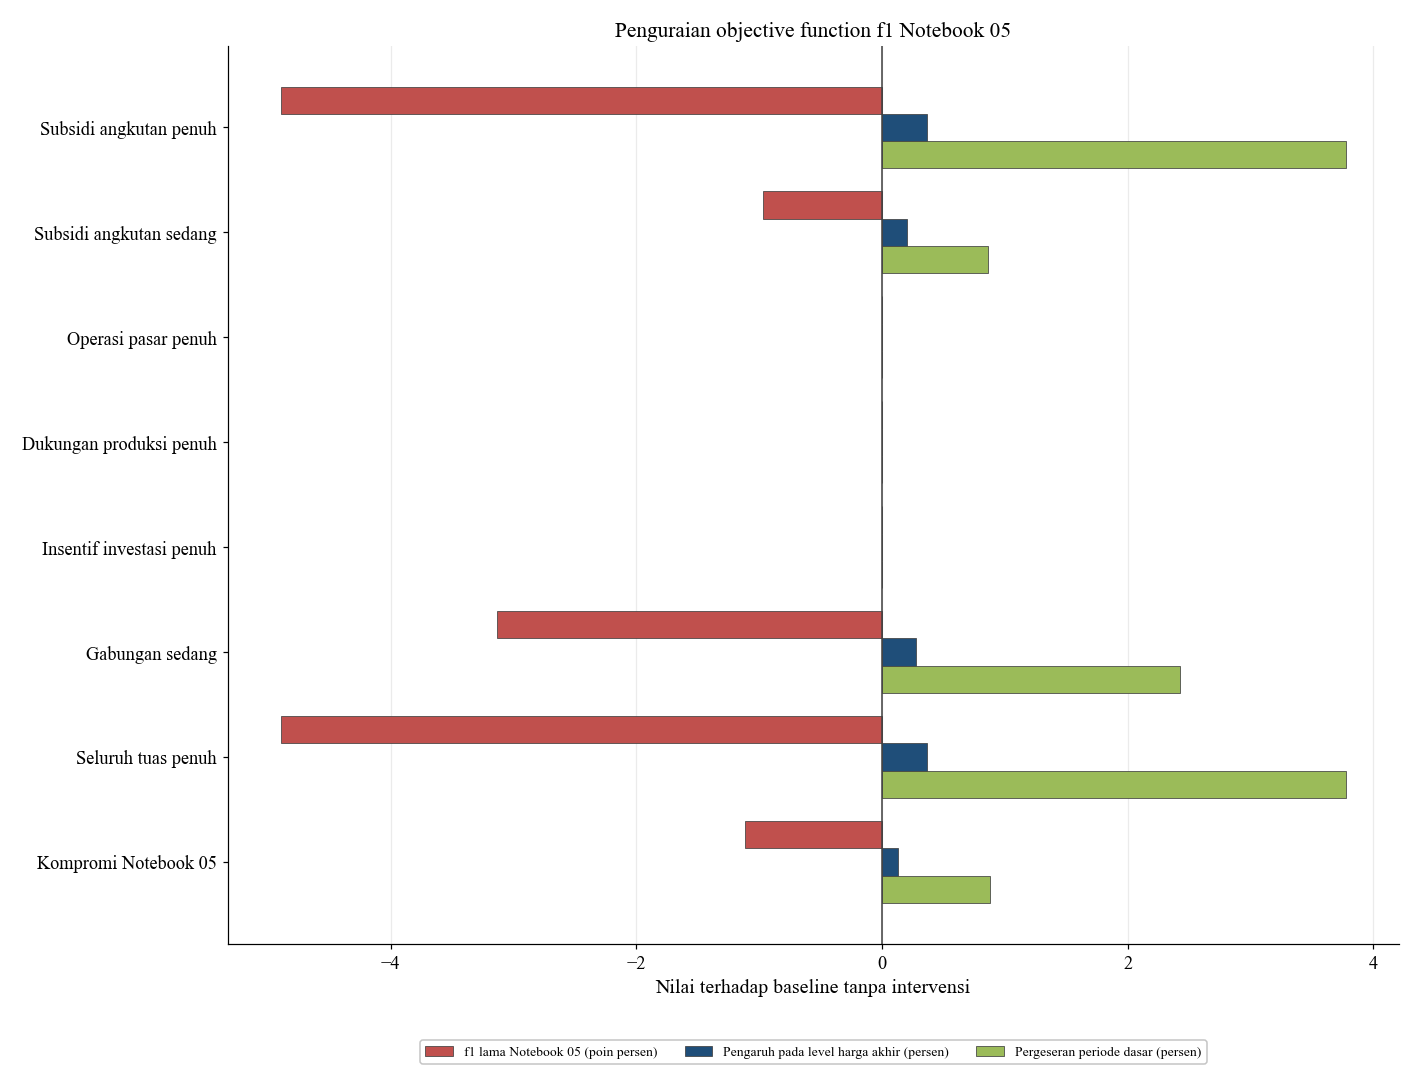

Gambar 1 disimpan. Batang merah yang mengarah ke kiri bersanding dengan batang
biru yang mengarah ke kanan pada kebijakan yang sama menandakan dua kesimpulan
berlawanan dari satu simulasi yang sama, dan itulah bentuk cacatnya.


In [4]:
# Sel 2.2 - Gambar 1: penguraian f1 lama

v6_tabel = DEKOMPOSISI_F1[DEKOMPOSISI_F1.kebijakan != "Tanpa intervensi"].copy()
v6_tabel = v6_tabel.iloc[::-1].reset_index(drop=True)
v6_y = np.arange(len(v6_tabel))
v6_tinggi = 0.26

fig, ax = plt.subplots(figsize=(12.6, 0.92 * len(v6_tabel) + 2.2))
ax.barh(v6_y + v6_tinggi, v6_tabel["f1_lama_poin_persen"], height=v6_tinggi,
        color=PALET[1], edgecolor="0.25", linewidth=0.5,
        label="f1 lama Notebook 05 (poin persen)")
ax.barh(v6_y, v6_tabel["pengaruh_level_akhir_persen"], height=v6_tinggi,
        color=PALET[0], edgecolor="0.25", linewidth=0.5,
        label="Pengaruh pada level harga akhir (persen)")
ax.barh(v6_y - v6_tinggi, v6_tabel["pergeseran_periode_dasar_persen"],
        height=v6_tinggi, color=PALET[3], edgecolor="0.25", linewidth=0.5,
        label="Pergeseran periode dasar (persen)")
ax.axvline(0.0, color="0.25", linewidth=1.0)
ax.set_yticks(v6_y)
ax.set_yticklabels(v6_tabel["kebijakan"])
ax.set_xlabel("Nilai terhadap baseline tanpa intervensi")
ax.set_title("Penguraian objective function f1 Notebook 05")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=3,
          fontsize=UKURAN - 4, frameon=True)
ax.grid(axis="y", visible=False)
simpan_gambar(fig, "gambar_01_dekomposisi_f1",
              "Penguraian f1 lama menjadi pengaruh level akhir dan pergeseran dasar")
plt.show()

print("Gambar 1 disimpan. Batang merah yang mengarah ke kiri bersanding dengan batang")
print("biru yang mengarah ke kanan pada kebijakan yang sama menandakan dua kesimpulan")
print("berlawanan dari satu simulasi yang sama, dan itulah bentuk cacatnya.")

# Bagian 3. Screening Tuas Kebijakan

Sebelum tujuan didefinisikan ulang, perlu diketahui lebih dahulu tujuan mana yang
sebenarnya dapat digerakkan oleh tuas mana. Pemeriksaan ini bukan pelengkap. Ia
menentukan apakah suatu pertukaran yang muncul pada *Pareto front* (himpunan solusi tak
terdominasi) benar benar berasal dari pilihan kebijakan, atau hanya artefak dari
tuas yang secara struktural tidak menyentuh besaran yang bersangkutan.

Metodenya adalah *one-factor-at-a-time* atau OAT (pengubahan satu faktor pada satu
waktu), yaitu setiap kelompok tuas dinaikkan ke batas atasnya sementara tuas lain
ditahan pada nilai tanpa intervensi. Saltelli dan Annoni (2010) menunjukkan bahwa OAT
tidak memadai sebagai analisis sensitivitas yang lengkap karena tidak menangkap
interaksi dan hanya menjelajahi sebagian kecil ruang masukan. Di sini OAT dipakai bukan
untuk mengukur besarnya pengaruh, melainkan untuk satu pertanyaan yang jauh lebih
sempit dan memang dapat dijawab OAT, yaitu apakah pengaruh sebuah tuas pada sebuah
besaran persis nol atau tidak. Pengaruh nol pada penjalanan tunggal dengan tuas
dimaksimalkan sudah cukup membuktikan bahwa jalur sebab akibatnya memang tidak ada di
dalam model, sebab bila jalurnya ada, pengaruhnya tidak mungkin nol persis. Besarnya
pengaruh tetap diukur pada propagasi ketidakpastian di Bagian 6 yang menarik seluruh
parameter secara bersamaan.

In [5]:
# Sel 3.1 - Screening tuas kebijakan satu per satu

V6_KELOMPOK_TUAS = [
    ("Subsidi angkutan", ["s_ang", "f_ang"], [1.0, 0.6, 0.0, 1.0, 0.0, 0.0, 0.0]),
    ("Cadangan dan operasi pasar", ["cap_op", "amb_op"],
     [0.0, 0.0, 0.5, 3.0, 0.0, 0.0, 0.0]),
    ("Dukungan produksi", ["s_prod", "f_prod"], [0.0, 0.0, 0.0, 1.0, 0.3, 0.6, 0.0]),
    ("Insentif investasi", ["s_inv"], [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.5]),
]

V6_BESARAN = [
    ("level_harga_akhir", "Level harga pangan akhir", "persen"),
    ("dispersi_harga_akhir", "Dispersi harga antarwilayah", "persen"),
    ("kekurangan_pasokan_persen", "Kekurangan pasokan", "persen"),
    ("ntp_akhir", "Nilai tukar petani", "persen"),
    ("kemiskinan_akhir_persen", "Tingkat kemiskinan", "persen"),
    ("pengangguran_akhir_persen", "Tingkat pengangguran terbuka", "persen"),
    ("gini_akhir", "Rasio Gini", "persen"),
    ("laju_pdrb_tahunan_persen", "Laju PDRB tahunan", "poin persen"),
]

# Ambang nol numerik. Deviasi di bawah ambang ini diperlakukan sebagai nol struktural,
# bukan sebagai pengaruh kecil, sebab galat pembulatan aritmetika titik kambang pada
# horizon tiga tahun berada jauh di bawahnya.
V6_AMBANG_NOL = 1e-9

v6_baris = []
for v6_nama, v6_kode, v6_x in V6_KELOMPOK_TUAS:
    v6_R = jalankan_kebijakan(np.array(v6_x, float))
    v6_r = v6_ringkas(v6_R)
    v6_rec = {"tuas": v6_nama, "peubah_keputusan": " dan ".join(v6_kode),
              "biaya_triliun": v6_R["_biaya"]["total"] / 1e12}
    for v6_kol, v6_label, v6_sat in V6_BESARAN:
        v6_a = float(v6_r[v6_kol])
        v6_b = float(V6_DASAR[v6_kol])
        if v6_sat == "poin persen":
            v6_nilai = v6_a - v6_b
        else:
            v6_nilai = 100.0 * (v6_a / v6_b - 1.0) if abs(v6_b) > 1e-12 else np.nan
        v6_rec[v6_kol] = v6_nilai
    v6_baris.append(v6_rec)

SCREENING_TUAS = pd.DataFrame(v6_baris)
simpan(SCREENING_TUAS, "tabel/screening_tuas_kebijakan.csv")

# Matriks keterhubungan. True berarti tuas menggerakkan besaran itu sama sekali.
V6_HUBUNG = pd.DataFrame(
    {v6_kol: (SCREENING_TUAS[v6_kol].abs() > V6_AMBANG_NOL).to_numpy()
     for v6_kol, _, _ in V6_BESARAN},
    index=SCREENING_TUAS["tuas"])
simpan(V6_HUBUNG.astype(int), "mutu/matriks_keterhubungan_tuas.csv", indeks=True)

print("=" * 78)
print("SCREENING TUAS KEBIJAKAN, setiap kelompok tuas dinaikkan ke batas atasnya")
print("=" * 78)
print("Angka menyatakan perubahan relatif terhadap baseline dalam persen, kecuali laju")
print("PDRB yang dinyatakan dalam poin persen per tahun. Tanda titik berarti persis nol.")
print()
print("  " + "tuas".ljust(28) + "".join(
    (v6_l.split()[0][:9]).rjust(11) for _, v6_l, _ in V6_BESARAN) + "biaya T".rjust(10))
for v6_rec in SCREENING_TUAS.itertuples():
    v6_sel_teks = ""
    for v6_kol, _, _ in V6_BESARAN:
        v6_v = float(getattr(v6_rec, v6_kol))
        v6_sel_teks += ("." .rjust(11) if abs(v6_v) <= V6_AMBANG_NOL
                        else format(v6_v, "11.4f"))
    print("  " + v6_rec.tuas.ljust(28) + v6_sel_teks
          + format(v6_rec.biaya_triliun, "10.3f"))
print()
print("  Kepala kolom berurut:", ", ".join(v6_l for _, v6_l, _ in V6_BESARAN))
print()

print("Interpretasi otomatis:")
for v6_kol, v6_label, _ in V6_BESARAN:
    v6_hidup = [SCREENING_TUAS.loc[v6_i, "tuas"]
                for v6_i in range(len(SCREENING_TUAS))
                if abs(float(SCREENING_TUAS.loc[v6_i, v6_kol])) > V6_AMBANG_NOL]
    if len(v6_hidup) == 0:
        print("  " + v6_label + ": tidak ada satu pun tuas yang menggerakkannya.")
    else:
        print("  " + v6_label + ": digerakkan oleh " + ", ".join(v6_hidup) + ".")
print()

v6_n_mati = int((~V6_HUBUNG.to_numpy()).sum())
v6_n_sel = int(V6_HUBUNG.size)
print("  Dari", v6_n_sel, "pasangan tuas dan besaran,", v6_n_mati,
      "pasangan bernilai nol persis.")
print("  Nol persis berarti jalur sebab akibatnya tidak ada di dalam struktur model,")
print("  bukan berarti pengaruhnya kecil. Konsekuensinya, tujuan yang hanya dapat")
print("  digerakkan oleh satu tuas tidak menghasilkan pertukaran terhadap tujuan lain")
print("  yang juga hanya digerakkan tuas yang sama.")

# Pemeriksaan efisiensi biaya untuk besaran yang dapat dicapai lebih dari satu tuas
v6_kandidat = SCREENING_TUAS[
    SCREENING_TUAS["kekurangan_pasokan_persen"].abs() > V6_AMBANG_NOL].copy()
if len(v6_kandidat) >= 2:
    v6_kandidat["biaya_per_poin"] = (
        v6_kandidat["biaya_triliun"]
        / v6_kandidat["kekurangan_pasokan_persen"].abs().replace(0, np.nan))
    v6_kandidat = v6_kandidat.sort_values("biaya_per_poin")
    print()
    print("  Efisiensi biaya menurunkan kekurangan pasokan, triliun rupiah per satu")
    print("  persen penurunan relatif:")
    for v6_rec in v6_kandidat.itertuples():
        print("    " + v6_rec.tuas.ljust(30),
              format(float(v6_rec.biaya_per_poin), "10.5f"))

SCREENING TUAS KEBIJAKAN, setiap kelompok tuas dinaikkan ke batas atasnya
Angka menyatakan perubahan relatif terhadap baseline dalam persen, kecuali laju
PDRB yang dinyatakan dalam poin persen per tahun. Tanda titik berarti persis nol.

  tuas                              Level   Dispersi  Kekuranga      Nilai    Tingkat    Tingkat      Rasio       Laju   biaya T
  Subsidi angkutan                 0.3660   -32.8981   -19.3391     0.0665     0.0991          .    -0.0107          .     1.740
  Cadangan dan operasi pasar            .          .  -100.0000          .          .          .          .          .     6.501
  Dukungan produksi                     .          .  -100.0000          .          .          .          .          .     0.026
  Insentif investasi                    .          .     0.5231          .    -0.5202    -0.7861    -0.0521     0.8914     7.109

  Kepala kolom berurut: Level harga pangan akhir, Dispersi harga antarwilayah, Kekurangan pasokan, Nilai tukar petani

## 3.2 Gambar keterhubungan tuas dan besaran

Gambar berikut menampilkan besarnya pengaruh setiap kelompok tuas pada setiap besaran
dalam bentuk matriks berwarna. Sel yang diberi tanda silang adalah sel yang nilainya
nol persis, yaitu sel yang jalur sebab akibatnya tidak ada di dalam model. Skala warna
dipisah per kolom karena satuan antarkolom tidak sebanding, sehingga yang dapat dibaca
dari warna hanyalah arah dan besar relatif di dalam satu kolom.

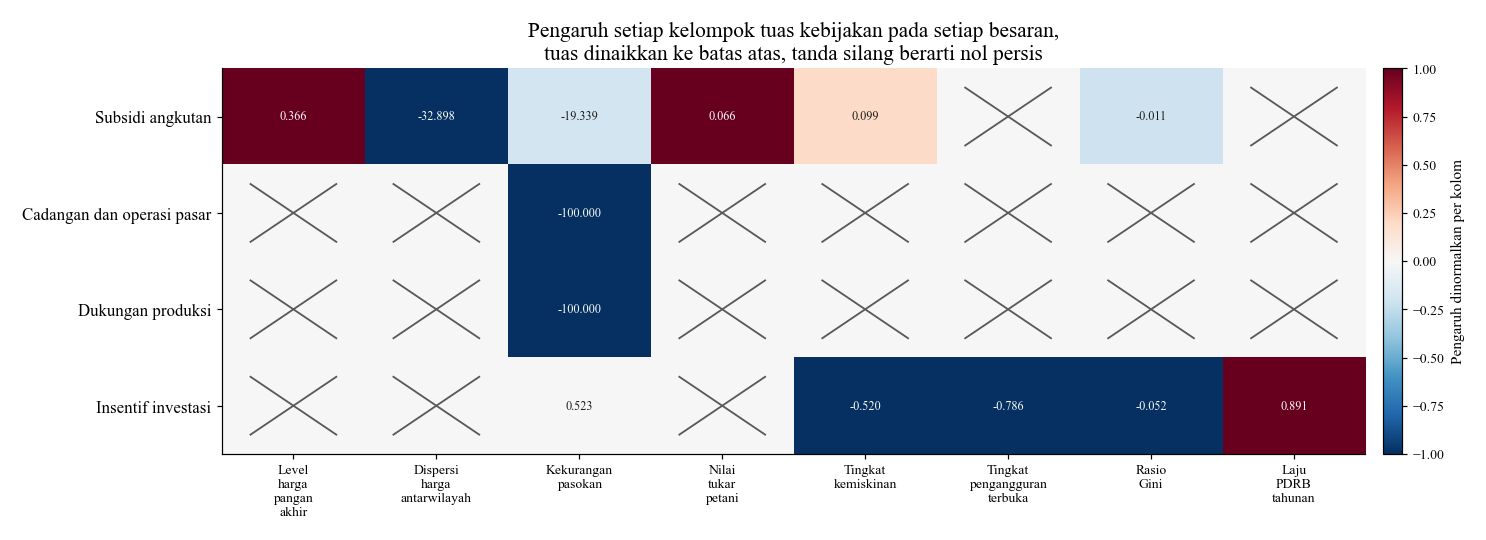

Gambar 2 disimpan. Jumlah sel bertanda silang: 19 dari 32 sel.


In [6]:
# Sel 3.2 - Gambar 2: matriks keterhubungan tuas dan besaran

v6_kolom = [v6_k for v6_k, _, _ in V6_BESARAN]
v6_label_kolom = [v6_l for _, v6_l, _ in V6_BESARAN]
v6_M = SCREENING_TUAS[v6_kolom].to_numpy(float)
v6_baris_label = SCREENING_TUAS["tuas"].tolist()

# Normalisasi per kolom agar warna dapat dibandingkan di dalam satu kolom
v6_N = np.zeros_like(v6_M)
for v6_j in range(v6_M.shape[1]):
    v6_skala = np.max(np.abs(v6_M[:, v6_j]))
    v6_N[:, v6_j] = v6_M[:, v6_j] / v6_skala if v6_skala > V6_AMBANG_NOL else 0.0

fig, ax = plt.subplots(figsize=(13.2, 4.6))
v6_gbr = ax.imshow(v6_N, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(np.arange(len(v6_label_kolom)))
ax.set_xticklabels([v6_t.replace(" ", "\n") for v6_t in v6_label_kolom],
                   fontsize=UKURAN - 4)
ax.set_yticks(np.arange(len(v6_baris_label)))
ax.set_yticklabels(v6_baris_label, fontsize=UKURAN - 2)
ax.grid(False)
for v6_i in range(v6_M.shape[0]):
    for v6_j in range(v6_M.shape[1]):
        if abs(v6_M[v6_i, v6_j]) <= V6_AMBANG_NOL:
            ax.plot([v6_j - 0.30, v6_j + 0.30], [v6_i - 0.30, v6_i + 0.30],
                    color="0.35", linewidth=1.2)
            ax.plot([v6_j - 0.30, v6_j + 0.30], [v6_i + 0.30, v6_i - 0.30],
                    color="0.35", linewidth=1.2)
        else:
            ax.text(v6_j, v6_i, format(v6_M[v6_i, v6_j], ".3f"),
                    ha="center", va="center", fontsize=UKURAN - 5,
                    color="0.10" if abs(v6_N[v6_i, v6_j]) < 0.6 else "white")
ax.set_title("Pengaruh setiap kelompok tuas kebijakan pada setiap besaran,\n"
             "tuas dinaikkan ke batas atas, tanda silang berarti nol persis")
v6_bar = fig.colorbar(v6_gbr, ax=ax, fraction=0.020, pad=0.015)
v6_bar.set_label("Pengaruh dinormalkan per kolom", fontsize=UKURAN - 3)
v6_bar.ax.tick_params(labelsize=UKURAN - 4)
simpan_gambar(fig, "gambar_02_keterhubungan_tuas",
              "Matriks keterhubungan antara kelompok tuas kebijakan dan besaran hasil")
plt.show()

print("Gambar 2 disimpan. Jumlah sel bertanda silang:",
      int((np.abs(v6_M) <= V6_AMBANG_NOL).sum()), "dari", int(v6_M.size), "sel.")

# Bagian 4. Definisi Ulang Objective Function

## 4.1 Bentuk baru

Setiap tujuan sekarang dinyatakan sebagai selisih *level* pada akhir horizon terhadap
*baseline* pada akhir horizon, bukan sebagai selisih laju pertumbuhan sepanjang horizon.
Dengan cara ini periode dasar tidak lagi ikut bergerak ketika kebijakan dijalankan,
sehingga nilai tujuan hanya memuat pengaruh kebijakan.

Dua himpunan tujuan dijalankan.

Himpunan **asli** mempertahankan keenam tujuan Notebook 05 agar hasilnya tetap dapat
dibandingkan, dengan satu perubahan yaitu f1 diganti menjadi pengaruh pada level harga
pangan akhir:

    f1 = 100 * ( level harga akhir dengan kebijakan / level harga akhir baseline - 1 )
    f2 = -( nilai tukar petani akhir - baseline )
    f3 = tingkat kemiskinan akhir - baseline
    f4 = tingkat pengangguran terbuka akhir - baseline
    f5 = rasio Gini akhir - baseline
    f6 = -( laju PDRB tahunan - baseline )

Himpunan **revisi** menggantikan dua tujuan yang bermasalah dengan dua besaran sisi
pasokan yang justru merupakan inti tema ketahanan pangan. Tujuan pengangguran dibuang
karena Notebook 05 sudah membuktikan bahwa ia merupakan transformasi monoton dari
pertumbuhan PDRB dengan korelasi peringkat satu persis, sehingga ia tidak membawa
informasi baru. Rasio Gini juga dibuang karena diagnostik keterbedaan Notebook 05
menunjukkan nisbah sinyal terhadap derau di bawah satu, sehingga peringkat antarkebijakan
pada tujuan itu tidak dapat dipertanggungjawabkan. Sebagai gantinya masuk dispersi harga
antarwilayah dan kekurangan pasokan:

    g1 = 100 * ( level harga akhir dengan kebijakan / level harga akhir baseline - 1 )
    g2 = -( nilai tukar petani akhir - baseline )
    g3 = tingkat kemiskinan akhir - baseline
    g4 = -( laju PDRB tahunan - baseline )
    g5 = 100 * ( dispersi harga akhir / dispersi harga akhir baseline - 1 )
    g6 = kekurangan pasokan - baseline

Seluruh tujuan diminimumkan secara internal, sehingga tujuan yang sebenarnya ingin
dinaikkan disimpan bertanda negatif. Jumlah tujuan pada kedua himpunan sama, yaitu enam,
sehingga ukuran populasi dan jumlah *reference direction* Das dan Dennis tetap sama dan
waktu pencarian kedua himpunan sebanding.

In [7]:
# Sel 4.1 - Definisi ulang tujuan dan pemeriksaan baseline


def v6_t_level_harga(r, d):
    return 100.0 * (r["level_harga_akhir"] / d["level_harga_akhir"] - 1.0)


def v6_t_ntp(r, d):
    return -(r["ntp_akhir"] - d["ntp_akhir"])


def v6_t_miskin(r, d):
    return r["kemiskinan_akhir_persen"] - d["kemiskinan_akhir_persen"]


def v6_t_tpt(r, d):
    return r["pengangguran_akhir_persen"] - d["pengangguran_akhir_persen"]


def v6_t_gini(r, d):
    return r["gini_akhir"] - d["gini_akhir"]


def v6_t_pdrb(r, d):
    return -(r["laju_pdrb_tahunan_persen"] - d["laju_pdrb_tahunan_persen"])


def v6_t_dispersi(r, d):
    return 100.0 * (r["dispersi_harga_akhir"] / d["dispersi_harga_akhir"] - 1.0)


def v6_t_kekurangan(r, d):
    return r["kekurangan_pasokan_persen"] - d["kekurangan_pasokan_persen"]


# Setiap tujuan berisi kode, nama Indonesia, padanan asing, satuan, tanda tampilan,
# dan fungsi penghitungnya. Tanda tampilan mengembalikan arah alami saat digambar.
V6_TUJUAN = {
    "asli": [
        ("f1", "Level harga pangan akhir", "terminal food price level",
         "persen terhadap baseline", +1, v6_t_level_harga),
        ("f2", "Nilai tukar petani", "farmers terms of trade",
         "poin indeks terhadap baseline", -1, v6_t_ntp),
        ("f3", "Tingkat kemiskinan", "poverty rate",
         "poin persen terhadap baseline", +1, v6_t_miskin),
        ("f4", "Tingkat pengangguran terbuka", "unemployment rate",
         "poin persen terhadap baseline", +1, v6_t_tpt),
        ("f5", "Rasio Gini", "Gini coefficient",
         "poin terhadap baseline", +1, v6_t_gini),
        ("f6", "Pertumbuhan PDRB", "GRDP growth",
         "poin persen per tahun terhadap baseline", -1, v6_t_pdrb),
    ],
    "revisi": [
        ("g1", "Level harga pangan akhir", "terminal food price level",
         "persen terhadap baseline", +1, v6_t_level_harga),
        ("g2", "Nilai tukar petani", "farmers terms of trade",
         "poin indeks terhadap baseline", -1, v6_t_ntp),
        ("g3", "Tingkat kemiskinan", "poverty rate",
         "poin persen terhadap baseline", +1, v6_t_miskin),
        ("g4", "Pertumbuhan PDRB", "GRDP growth",
         "poin persen per tahun terhadap baseline", -1, v6_t_pdrb),
        ("g5", "Dispersi harga antarwilayah", "cross district price dispersion",
         "persen terhadap baseline", +1, v6_t_dispersi),
        ("g6", "Kekurangan pasokan", "supply shortfall",
         "poin persen terhadap baseline", +1, v6_t_kekurangan),
    ],
}

V6_KODE_TUJUAN = {k: [d[0] for d in v] for k, v in V6_TUJUAN.items()}
V6_NAMA_TUJUAN = {k: [d[0] + " " + d[1] for d in v] for k, v in V6_TUJUAN.items()}
V6_TANDA_TAMPIL = {k: np.array([d[4] for d in v], float) for k, v in V6_TUJUAN.items()}
V6_LABEL_TUJUAN = {
    k: [d[0] + " " + d[1] + "\n(" + d[3] + ",\n"
        + ("makin rendah makin baik" if d[4] > 0 else "makin tinggi makin baik") + ")"
        for d in v] for k, v in V6_TUJUAN.items()}
V6_NM = 6


def v6_vektor_tujuan(set_nama, r, d):
    """Enam nilai tujuan untuk satu ringkasan hasil terhadap satu baseline."""
    return np.array([fn(r, d) for (_, _, _, _, _, fn) in V6_TUJUAN[set_nama]], float)


def v6_evaluasi(x, biaya=None, **kw):
    """Jalankan satu vektor kebijakan dan kembalikan ringkasan serta biayanya."""
    R = jalankan_kebijakan(np.asarray(x, float), biaya=biaya, rekam=True, **kw)
    return v6_ringkas(R), R["_biaya"], R


def v6_buat_fungsi(set_nama, ref, pagu, biaya=None, **kw):
    """Bungkus tujuan menjadi fungsi berkelompok untuk algoritma evolusioner."""
    def fungsi(X):
        X = np.atleast_2d(X)
        F = np.zeros((len(X), V6_NM))
        G = np.zeros(len(X))
        for v6_i in range(len(X)):
            v6_r, v6_b, _ = v6_evaluasi(X[v6_i], biaya=biaya, **kw)
            F[v6_i] = v6_vektor_tujuan(set_nama, v6_r, ref)
            G[v6_i] = max(0.0, (v6_b["total"] - pagu) / 1e12)
        return F, G
    return fungsi


print("=" * 78)
print("DEFINISI TUJUAN SETELAH KOREKSI")
print("=" * 78)
for v6_set in ["asli", "revisi"]:
    print()
    print("  Himpunan", v6_set.upper())
    print("  " + "kode".ljust(6) + "nama".ljust(32) + "padanan asing".ljust(32) + "arah")
    for v6_d in V6_TUJUAN[v6_set]:
        print("  " + v6_d[0].ljust(6) + v6_d[1].ljust(32) + v6_d[2].ljust(32)
              + ("minimum" if v6_d[4] > 0 else "maksimum"))

print()
print("Pemeriksaan baseline. Seluruh tujuan seharusnya bernilai nol persis pada vektor")
print("kebijakan tanpa intervensi, sebab tujuan dinyatakan sebagai selisih terhadap")
print("baseline itu sendiri.")
V6_NOL_BASELINE = {}
for v6_set in ["asli", "revisi"]:
    v6_f0 = v6_vektor_tujuan(v6_set, V6_DASAR, V6_DASAR)
    V6_NOL_BASELINE[v6_set] = float(np.abs(v6_f0).max())
    print("  himpunan", v6_set.ljust(8), "simpangan mutlak terbesar:",
          format(V6_NOL_BASELINE[v6_set], ".3e"),
          "->", "SESUAI" if V6_NOL_BASELINE[v6_set] < 1e-12 else "PERIKSA KEMBALI")
if max(V6_NOL_BASELINE.values()) >= 1e-12:
    raise RuntimeError("Penyelisihan terhadap baseline tidak bekerja benar.")

V6_N_EVAL = N_POP * (1 + N_GEN)
print()
print("  evaluasi per pencarian:", format(V6_N_EVAL, ","),
      "| perkiraan", format(V6_N_EVAL * V6_DETIK_EVAL / 60, ".1f"), "menit")

DEFINISI TUJUAN SETELAH KOREKSI

  Himpunan ASLI
  kode  nama                            padanan asing                   arah
  f1    Level harga pangan akhir        terminal food price level       minimum
  f2    Nilai tukar petani              farmers terms of trade          maksimum
  f3    Tingkat kemiskinan              poverty rate                    minimum
  f4    Tingkat pengangguran terbuka    unemployment rate               minimum
  f5    Rasio Gini                      Gini coefficient                minimum
  f6    Pertumbuhan PDRB                GRDP growth                     maksimum

  Himpunan REVISI
  kode  nama                            padanan asing                   arah
  g1    Level harga pangan akhir        terminal food price level       minimum
  g2    Nilai tukar petani              farmers terms of trade          maksimum
  g3    Tingkat kemiskinan              poverty rate                    minimum
  g4    Pertumbuhan PDRB                GRDP growth    

## 4.2 Uji konsistensi antara nilai agregat dan tabel per wilayah

Cacat pada f1 lama pertama kali terlihat dari ketidakcocokan antara nilai agregat dan
tabel dampak per kabupaten dan kota. Karena itu konsistensi keduanya sekarang diuji
secara eksplisit dan otomatis. Nilai tujuan pertama pada bentuk barunya harus sama
persis dengan rata rata tertimbang penduduk atas perubahan indeks harga pangan akhir
per wilayah, sebab keduanya menghitung besaran yang sama.

Perlu dicatat bahwa yang harus sama adalah rata rata tertimbang atas *level*, bukan
rata rata tertimbang atas perubahan persentase per wilayah. Keduanya berbeda karena
rata rata rasio tidak sama dengan rasio rata rata. Uji berikut memakai bentuk yang
benar, yaitu rasio antara dua rata rata tertimbang level, dan sekaligus melaporkan
selisihnya terhadap bentuk yang salah supaya besarnya dapat dinilai.

In [8]:
# Sel 4.2 - Uji konsistensi agregat terhadap tabel per wilayah

V6_X_UJI_KONS = np.array([0.5, 0.4, 0.12, 1.5, 0.08, 0.4, 0.15], float)
V6_R_UJI_KONS = jalankan_kebijakan(V6_X_UJI_KONS)
V6_RING_UJI_KONS = v6_ringkas(V6_R_UJI_KONS)

v6_bobot = V6_R_UJI_KONS["pop"][-1]
v6_ihp_kebijakan = V6_R_UJI_KONS["ihp"][-1]
v6_ihp_dasar = V6_R_DASAR["ihp"][-1]

v6_agregat = 100.0 * (float(np.average(v6_ihp_kebijakan, weights=v6_bobot))
                      / float(np.average(v6_ihp_dasar, weights=v6_bobot)) - 1.0)
v6_dari_tujuan = v6_t_level_harga(V6_RING_UJI_KONS, V6_DASAR)
v6_per_wilayah = 100.0 * (v6_ihp_kebijakan / v6_ihp_dasar - 1.0)
v6_rata_rasio = float(np.average(v6_per_wilayah, weights=v6_bobot))

KONSISTENSI_AGREGAT = pd.DataFrame([{
    "besaran": "Nilai tujuan pertama dari fungsi tujuan",
    "nilai_persen": v6_dari_tujuan},
    {"besaran": "Rasio antara dua rata rata tertimbang level",
     "nilai_persen": v6_agregat},
    {"besaran": "Rata rata tertimbang atas perubahan persentase per wilayah",
     "nilai_persen": v6_rata_rasio},
    {"besaran": "Wilayah dengan indeks harga pangan akhir naik",
     "nilai_persen": float((v6_per_wilayah > 0).sum())},
    {"besaran": "Wilayah dengan indeks harga pangan akhir turun",
     "nilai_persen": float((v6_per_wilayah < 0).sum())}])
simpan(KONSISTENSI_AGREGAT, "mutu/uji_konsistensi_agregat_wilayah.csv")

V6_GALAT_KONSISTENSI = abs(v6_dari_tujuan - v6_agregat)

print("=" * 78)
print("UJI KONSISTENSI ANTARA NILAI AGREGAT DAN TABEL PER WILAYAH")
print("=" * 78)
print("  kebijakan uji:", ", ".join(
    k + " = " + format(float(v), ".3f") for k, v in zip(KODE_X, V6_X_UJI_KONS)))
print()
print("  nilai tujuan pertama dari fungsi tujuan      :",
      format(v6_dari_tujuan, "+.6f"), "persen")
print("  rasio antara dua rata rata tertimbang level  :",
      format(v6_agregat, "+.6f"), "persen")
print("  selisih keduanya                             :",
      format(V6_GALAT_KONSISTENSI, ".3e"),
      "->", "KONSISTEN" if V6_GALAT_KONSISTENSI < 1e-10 else "TIDAK KONSISTEN")
print()
print("  rata rata tertimbang atas perubahan persentase per wilayah:",
      format(v6_rata_rasio, "+.6f"), "persen")
print("  Perbedaan terhadap bentuk yang benar sebesar",
      format(abs(v6_rata_rasio - v6_agregat), ".6f"), "poin persen berasal dari")
print("  ketidaksamaan antara rata rata rasio dan rasio rata rata, dan karena itu")
print("  hanya bentuk pertama yang dipakai sebagai nilai tujuan.")
print()
print("  wilayah dengan indeks harga pangan akhir naik :",
      int((v6_per_wilayah > 0).sum()), "dari", NW)
print("  wilayah dengan indeks harga pangan akhir turun:",
      int((v6_per_wilayah < 0).sum()), "dari", NW)
if V6_GALAT_KONSISTENSI >= 1e-10:
    raise RuntimeError("Nilai agregat tidak konsisten dengan tabel per wilayah.")
print()
print("  Sejak titik ini, tanda nilai tujuan pertama dan tanda perubahan indeks harga")
print("  pangan akhir per wilayah tidak dapat lagi berlawanan, sebab keduanya dihitung")
print("  dari besaran yang sama.")

UJI KONSISTENSI ANTARA NILAI AGREGAT DAN TABEL PER WILAYAH
  kebijakan uji: s_ang = 0.500, f_ang = 0.400, cap_op = 0.120, amb_op = 1.500, s_prod = 0.080, f_prod = 0.400, s_inv = 0.150

  nilai tujuan pertama dari fungsi tujuan      : +0.273312 persen
  rasio antara dua rata rata tertimbang level  : +0.273312 persen
  selisih keduanya                             : 0.000e+00 -> KONSISTEN

  rata rata tertimbang atas perubahan persentase per wilayah: +0.277023 persen
  Perbedaan terhadap bentuk yang benar sebesar 0.003711 poin persen berasal dari
  ketidaksamaan antara rata rata rasio dan rasio rata rata, dan karena itu
  hanya bentuk pertama yang dipakai sebagai nilai tujuan.

  wilayah dengan indeks harga pangan akhir naik : 30 dari 33
  wilayah dengan indeks harga pangan akhir turun: 3 dari 33

  Sejak titik ini, tanda nilai tujuan pertama dan tanda perubahan indeks harga
  pangan akhir per wilayah tidak dapat lagi berlawanan, sebab keduanya dihitung
  dari besaran yang sama.


# Bagian 5. Penjalanan Ulang Pencarian Pareto Front

Pencarian memakai NSGA-III menurut Deb dan Jain (2014), yaitu algoritma yang dirancang
untuk masalah dengan lebih dari tiga tujuan, dengan *niche preservation* pada
*reference direction* Das dan Dennis menggantikan *crowding distance*. Implementasinya
adalah implementasi Notebook 05 yang sudah diverifikasi terhadap masalah uji ZDT1 dan
DTLZ2, dan tidak diubah sama sekali di sini. Yang berubah hanya fungsi tujuannya.

Himpunan revisi dijalankan pada tiga tingkat pagu anggaran, yaitu setengah persen, satu
persen, dan dua persen dari belanja daerah gabungan, agar bentuk pertukaran dapat
dibandingkan antartingkat pagu. Himpunan asli dijalankan hanya pada pagu utama satu
persen, cukup untuk keperluan perbandingan dengan Notebook 05.

In [9]:
# Sel 5.1 - Menjalankan NSGA-III pada himpunan tujuan yang sudah dikoreksi


def v6_lacak(X, F, G, gen):
    layak = G <= 0
    Fl = F[layak] if layak.any() else F
    acuan = np.percentile(Fl, 95, axis=0) + 1e-6
    return {"generasi": gen, "n_layak": int(layak.sum()),
            "hypervolume": hypervolume(Fl[urutan_tak_terdominasi(Fl)[0]], acuan)}


def v6_cari_pareto(set_nama, label, pagu):
    """Jalankan NSGA-III satu kali dan kembalikan Pareto front beserta rinciannya."""
    fungsi = v6_buat_fungsi(set_nama, V6_DASAR, pagu)
    v6_awal = time.perf_counter()
    hasil = nsga3(fungsi, X_LO, X_HI, n_pop=N_POP, n_gen=N_GEN, p_bagi=P_BAGI,
                  n_tujuan=V6_NM, lacak=v6_lacak)
    detik = time.perf_counter() - v6_awal
    depan = hasil["depan"]
    layak = hasil["G"][depan] <= 0
    depan = depan[layak] if layak.any() else depan
    baris = []
    for v6_i in depan:
        v6_x = hasil["X"][v6_i]
        v6_r, v6_b, v6_R = v6_evaluasi(v6_x)
        v6_f = v6_vektor_tujuan(set_nama, v6_r, V6_DASAR)
        rec = {"himpunan": set_nama, "lengan": label, "pagu_triliun": pagu / 1e12}
        rec.update({k: float(v) for k, v in zip(KODE_X, v6_x)})
        rec.update({V6_KODE_TUJUAN[set_nama][j]: float(v6_f[j])
                    for j in range(V6_NM)})
        rec.update({
            "pelanggaran": float(max(0.0, (v6_b["total"] - pagu) / 1e12)),
            "biaya_total_triliun": v6_b["total"] / 1e12,
            "biaya_angkut_triliun": v6_b["angkut"] / 1e12,
            "biaya_operasi_triliun": v6_b["operasi"] / 1e12,
            "biaya_produksi_triliun": v6_b["produksi"] / 1e12,
            "biaya_insentif_triliun": v6_b["insentif"] / 1e12,
            "volume_antar_ton": v6_b["volume_antar_ton"],
            "volume_operasi_ton": v6_b["volume_operasi_ton"]})
        rec.update({k: float(v) for k, v in v6_r.items()})
        rec["f1_lama_setara_poin_persen"] = float(
            v6_r["kenaikan_harga_pangan_persen"]
            - V6_DASAR["kenaikan_harga_pangan_persen"])
        baris.append(rec)
    return pd.DataFrame(baris), pd.DataFrame(hasil["riwayat"]), detik


print("=" * 78)
print("PENCARIAN PARETO FRONT DENGAN TUJUAN YANG SUDAH DIKOREKSI")
print("=" * 78)
print("  perkiraan waktu total:",
      format((len(V6_SET_DIJALANKAN) - 1 + len(PANGSA_PAGU)) * V6_N_EVAL
             * V6_DETIK_EVAL / 60, ".0f"), "menit")
print()

V6_FRONT = {}
V6_RIWAYAT = {}
v6_kumpul = []
for v6_set in V6_SET_DIJALANKAN:
    v6_daftar_pagu = (list(zip(PANGSA_PAGU, PAGU_UJI)) if v6_set == V6_SET_UTAMA
                      else [(PANGSA_PAGU[1], PAGU_UTAMA)])
    for v6_pangsa, v6_pagu in v6_daftar_pagu:
        v6_label = v6_set + " pagu " + format(100 * v6_pangsa, ".1f") + " persen"
        v6_df, v6_rw, v6_dtk = v6_cari_pareto(v6_set, v6_label, v6_pagu)
        V6_FRONT[v6_label] = v6_df
        V6_RIWAYAT[v6_label] = v6_rw
        v6_kumpul.append(v6_df)
        print("  " + v6_label.ljust(30), format(len(v6_df), ">4"), "titik Pareto |",
              format(v6_dtk / 60, "5.1f"), "menit | biaya",
              format(v6_df.biaya_total_triliun.min(), ".3f"), "sampai",
              format(v6_df.biaya_total_triliun.max(), ".3f"), "triliun rupiah")

PARETO_V6 = pd.concat(v6_kumpul, ignore_index=True)
V6_LABEL_UTAMA = V6_SET_UTAMA + " pagu " + format(100 * PANGSA_PAGU[1], ".1f") + " persen"
PARETO_UTAMA_V6 = V6_FRONT[V6_LABEL_UTAMA].reset_index(drop=True)
simpan(PARETO_V6, "tabel/pareto_front_seluruh_v6.csv")
simpan(PARETO_UTAMA_V6, "tabel/pareto_front_utama_v6.csv")
simpan(pd.concat([v.assign(lengan=k) for k, v in V6_RIWAYAT.items()],
                 ignore_index=True), "mutu/konvergensi_optimisasi_v6.csv")

print()
print("RENTANG TUJUAN SEPANJANG PARETO FRONT UTAMA, himpunan", V6_SET_UTAMA)
print("  " + "tujuan".ljust(36) + "minimum".rjust(12) + "maksimum".rjust(12)
      + "rentang".rjust(12))
RENTANG_V6 = {}
for v6_j, v6_nm in enumerate(V6_NAMA_TUJUAN[V6_SET_UTAMA]):
    v6_c = V6_KODE_TUJUAN[V6_SET_UTAMA][v6_j]
    v6_lo = float(PARETO_UTAMA_V6[v6_c].min())
    v6_hi = float(PARETO_UTAMA_V6[v6_c].max())
    RENTANG_V6[v6_c] = v6_hi - v6_lo
    print("  " + v6_nm.ljust(36) + format(v6_lo, "12.5f") + format(v6_hi, "12.5f")
          + format(v6_hi - v6_lo, "12.5f"))

PENCARIAN PARETO FRONT DENGAN TUJUAN YANG SUDAH DIKOREKSI
  perkiraan waktu total: 55 menit

  revisi pagu 0.5 persen          128 titik Pareto |  14.4 menit | biaya 0.023 sampai 0.299 triliun rupiah
  revisi pagu 1.0 persen          128 titik Pareto |  13.8 menit | biaya 0.066 sampai 0.598 triliun rupiah
  revisi pagu 2.0 persen          128 titik Pareto |  13.8 menit | biaya 0.096 sampai 1.197 triliun rupiah
  asli pagu 1.0 persen            128 titik Pareto |  14.0 menit | biaya 0.061 sampai 0.599 triliun rupiah

RENTANG TUJUAN SEPANJANG PARETO FRONT UTAMA, himpunan revisi
  tujuan                                   minimum    maksimum     rentang
  g1 Level harga pangan akhir              0.00047     0.17708     0.17661
  g2 Nilai tukar petani                   -0.03835    -0.00006     0.03829
  g3 Tingkat kemiskinan                   -0.00446     0.00530     0.00976
  g4 Pertumbuhan PDRB                     -0.07508    -0.00000     0.07508
  g5 Dispersi harga antarwilayah         -

## 5.2 Perbandingan terhadap hasil Notebook 05

Perbandingan berikut menjawab satu pertanyaan, yaitu seberapa jauh kesimpulan berubah
setelah f1 diperbaiki. Yang dibandingkan adalah jumlah titik tak terdominasi, rentang
setiap tujuan, dan yang paling penting, tanda serta besar nilai tujuan pertama pada
solusi yang sama. Nilai f1 lama juga ikut dihitung ulang untuk setiap titik pada front
baru, sehingga besarnya artefak periode dasar dapat dilaporkan sebagai sebaran, bukan
hanya sebagai satu contoh.

In [10]:
# Sel 5.2 - Perbandingan hasil Notebook 06 terhadap Notebook 05

V6_PARETO_NB05 = None
if DIR_NB05 is not None and (DIR_NB05 / "tabel" / "pareto_front_utama.csv").exists():
    V6_PARETO_NB05 = pd.read_csv(DIR_NB05 / "tabel" / "pareto_front_utama.csv")

v6_baris = []
for v6_label, v6_df in V6_FRONT.items():
    v6_set = v6_df["himpunan"].iloc[0]
    v6_baris.append({
        "front": v6_label,
        "jumlah_titik": int(len(v6_df)),
        "biaya_min_triliun": float(v6_df.biaya_total_triliun.min()),
        "biaya_maks_triliun": float(v6_df.biaya_total_triliun.max()),
        "tujuan1_min": float(v6_df[V6_KODE_TUJUAN[v6_set][0]].min()),
        "tujuan1_maks": float(v6_df[V6_KODE_TUJUAN[v6_set][0]].max()),
        "titik_menurunkan_level_harga": int(
            (v6_df[V6_KODE_TUJUAN[v6_set][0]] < 0).sum()),
        "f1_lama_setara_min": float(v6_df["f1_lama_setara_poin_persen"].min()),
        "f1_lama_setara_maks": float(v6_df["f1_lama_setara_poin_persen"].max())})
if V6_PARETO_NB05 is not None:
    v6_baris.append({
        "front": "Notebook 05 pagu 1.0 persen",
        "jumlah_titik": int(len(V6_PARETO_NB05)),
        "biaya_min_triliun": float(V6_PARETO_NB05.biaya_total_triliun.min()),
        "biaya_maks_triliun": float(V6_PARETO_NB05.biaya_total_triliun.max()),
        "tujuan1_min": float(V6_PARETO_NB05.f1.min()),
        "tujuan1_maks": float(V6_PARETO_NB05.f1.max()),
        "titik_menurunkan_level_harga": np.nan,
        "f1_lama_setara_min": float(V6_PARETO_NB05.f1.min()),
        "f1_lama_setara_maks": float(V6_PARETO_NB05.f1.max())})

BANDING_FRONT = pd.DataFrame(v6_baris)
simpan(BANDING_FRONT, "tabel/perbandingan_front_nb05_nb06.csv")

print("=" * 78)
print("PERBANDINGAN PARETO FRONT")
print("=" * 78)
if V6_PARETO_NB05 is None:
    print("  Berkas pareto_front_utama.csv dari Notebook 05 tidak ditemukan, sehingga")
    print("  baris pembanding Notebook 05 tidak dapat ditampilkan. Jalankan Notebook 05")
    print("  sampai selesai lebih dahulu apabila baris itu diperlukan.")
    print()
print("  " + "front".ljust(30) + "titik".rjust(7) + "tujuan1 min".rjust(13)
      + "tujuan1 maks".rjust(14) + "turun harga".rjust(13) + "biaya maks".rjust(12))
for v6_rec in BANDING_FRONT.itertuples():
    v6_tn = ("-".rjust(13) if not np.isfinite(v6_rec.titik_menurunkan_level_harga)
             else format(int(v6_rec.titik_menurunkan_level_harga), "13d"))
    print("  " + v6_rec.front.ljust(30) + format(v6_rec.jumlah_titik, "7d")
          + format(v6_rec.tujuan1_min, "13.5f") + format(v6_rec.tujuan1_maks, "14.5f")
          + v6_tn + format(v6_rec.biaya_maks_triliun, "12.3f"))
print()

v6_u = PARETO_UTAMA_V6
v6_kode1 = V6_KODE_TUJUAN[V6_SET_UTAMA][0]
print("Interpretasi otomatis untuk front utama himpunan", V6_SET_UTAMA + ":")
print("  jumlah titik yang menurunkan level harga pangan akhir:",
      int((v6_u[v6_kode1] < 0).sum()), "dari", len(v6_u))
print("  jumlah titik yang menaikkan level harga pangan akhir :",
      int((v6_u[v6_kode1] > 0).sum()), "dari", len(v6_u))
print("  nilai f1 lama pada titik yang sama berkisar",
      format(float(v6_u["f1_lama_setara_poin_persen"].min()), ".4f"), "sampai",
      format(float(v6_u["f1_lama_setara_poin_persen"].max()), ".4f"), "poin persen.")
v6_menyesatkan = int(((v6_u[v6_kode1] > 0)
                      & (v6_u["f1_lama_setara_poin_persen"] < 0)).sum())
print("  jumlah titik yang pada definisi lama tampak menurunkan harga padahal level")
print("  harga akhirnya naik:", v6_menyesatkan, "dari", len(v6_u), "titik.")
if v6_menyesatkan > 0:
    print("  Angka ini adalah ukuran langsung seberapa luas kesalahan pembacaan yang")
    print("  akan terjadi bila definisi lama dipertahankan.")

PERBANDINGAN PARETO FRONT
  front                           titik  tujuan1 min  tujuan1 maks  turun harga  biaya maks
  revisi pagu 0.5 persen            128      0.00000       0.16963            0       0.299
  revisi pagu 1.0 persen            128      0.00047       0.17708            0       0.598
  revisi pagu 2.0 persen            128      0.00000       0.28370            0       1.197
  asli pagu 1.0 persen              128      0.00000       0.22947            0       0.599
  Notebook 05 pagu 1.0 persen       128     -1.82775      -0.00990            -       0.599

Interpretasi otomatis untuk front utama himpunan revisi:
  jumlah titik yang menurunkan level harga pangan akhir: 0 dari 128
  jumlah titik yang menaikkan level harga pangan akhir : 128 dari 128
  nilai f1 lama pada titik yang sama berkisar -0.4482 sampai 0.0712 poin persen.
  jumlah titik yang pada definisi lama tampak menurunkan harga padahal level
  harga akhirnya naik: 108 dari 128 titik.
  Angka ini adalah ukuran

# Bagian 6. Propagasi Ketidakpastian dan Diagnostik

## 6.1 Propagasi ketidakpastian dan minimax regret

Prosedurnya sama persis dengan Notebook 05, yaitu penarikan parameter secara acak
dengan *common random numbers* (bilangan acak bersama), sehingga setiap kebijakan
dinilai pada rangkaian keadaan dunia yang sama dan perbandingan antarkebijakan tidak
tercemar oleh perbedaan penarikan. Parameter yang ditarik meliputi koefisien penyesuaian
harga per wilayah dan komoditas, respons penawaran, elastisitas garis kemiskinan,
elastisitas kemiskinan, sepuluh parameter blok makro, serta empat biaya satuan.

Pemilihan solusi kompromi memakai kriteria *minimax regret* (penyesalan maksimum
terkecil) menurut Savage (1951), yaitu untuk setiap kebijakan dihitung penyesalan
maksimum atas seluruh keadaan dunia dan seluruh tujuan, lalu dipilih kebijakan dengan
penyesalan maksimum terkecil di antara kebijakan yang tetap layak secara anggaran pada
sekurang kurangnya delapan puluh persen penarikan.

In [11]:
# Sel 6.1 - Propagasi ketidakpastian dengan common random numbers

v6_acak = np.random.default_rng(20260827)

v6_se_theta = np.full((NW, NK), 0.08)
if "se_theta" in ECM.columns and "komoditas" in ECM.columns:
    for v6_a, v6_k in enumerate(KOM):
        v6_g = ECM[ECM.komoditas == v6_k]
        if "theta_sah" in v6_g.columns:
            v6_g = v6_g[v6_g.theta_sah]
        if len(v6_g) and v6_g["se_theta"].notna().any():
            v6_se_theta[:, v6_a] = float(v6_g["se_theta"].median())

V6_SIMPANGAN_MAKRO = 0.25
V6_DRAW = []
for v6_s in range(N_DRAW):
    v6_ak = float(np.clip(
        ALPHA_K * (1 + v6_acak.uniform(-V6_SIMPANGAN_MAKRO, V6_SIMPANGAN_MAKRO)),
        0.15, 0.60))
    V6_DRAW.append({
        "mak": {
            "alpha_k": v6_ak, "beta_l": 1.0 - v6_ak,
            "gamma_lk": GAMMA_LK * (1 + v6_acak.uniform(-V6_SIMPANGAN_MAKRO,
                                                        V6_SIMPANGAN_MAKRO)),
            "gamma_ln": GAMMA_LN * (1 + v6_acak.uniform(-V6_SIMPANGAN_MAKRO,
                                                        V6_SIMPANGAN_MAKRO)),
            "inv_y": INV_Y * (1 + v6_acak.uniform(-V6_SIMPANGAN_MAKRO,
                                                  V6_SIMPANGAN_MAKRO)),
            "gini_y": GINI_Y * (1 + v6_acak.uniform(-V6_SIMPANGAN_MAKRO,
                                                    V6_SIMPANGAN_MAKRO)),
            "gini_p": GINI_P * (1 + v6_acak.uniform(-V6_SIMPANGAN_MAKRO,
                                                    V6_SIMPANGAN_MAKRO)),
            "tpt_y": TPT_Y * (1 + v6_acak.uniform(-V6_SIMPANGAN_MAKRO,
                                                  V6_SIMPANGAN_MAKRO)),
            "delta_modal": DELTA_MODAL * (1 + v6_acak.uniform(-V6_SIMPANGAN_MAKRO,
                                                              V6_SIMPANGAN_MAKRO)),
            "e_ypc_p0": -0.20 * (1 + v6_acak.uniform(-V6_SIMPANGAN_MAKRO,
                                                     V6_SIMPANGAN_MAKRO))},
        "g_tfp": G_TFP_PAKAI * (1 + v6_acak.uniform(-V6_SIMPANGAN_MAKRO,
                                                    V6_SIMPANGAN_MAKRO)),
        "theta": np.clip(THETA + v6_acak.normal(0, v6_se_theta), -0.95, -0.02),
        "eta": float(v6_acak.uniform(ETA_LO, ETA_HI)),
        "e_gk": float(v6_acak.uniform(E_GK_STR_LO, E_GK_STR_HI)),
        "e_p0": float(v6_acak.uniform(E_P0_LO, E_P0_HI)),
        "biaya": {"angkut": BIAYA_ANGKUT_RP_TON * v6_acak.uniform(0.5, 1.5),
                  "operasi": BIAYA_OPERASI_RP_TON * v6_acak.uniform(0.5, 1.5),
                  "produksi": BIAYA_PRODUKSI_RP_HA_TAHUN * v6_acak.uniform(0.5, 1.5),
                  "insentif": BIAYA_INSENTIF_PER_RUPIAH * v6_acak.uniform(0.5, 1.5)}})


def v6_evaluasi_draw(x, d):
    """Nilai ringkasan dan biaya satu kebijakan pada satu penarikan parameter."""
    K = bangun_kebijakan(x)
    th = d["theta"].copy()
    if K["sasaran_ang"].any() and x[0] > 0:
        th[K["sasaran_ang"]] = np.clip(d["theta"][K["sasaran_ang"]] * (1 + x[0]),
                                       -0.95, -0.02)
    R = simulasi_penuh(theta=th, produksi=K["produksi"], kebijakan=K["kebijakan"],
                       inv0=INV0_PAKAI * K["inv_pengali"], rekam_aliran=True,
                       e_gk=d["e_gk"], e_p0=d["e_p0"], par={"eta": d["eta"]},
                       mak=d["mak"], g_tfp=d["g_tfp"])
    R["_x"] = np.asarray(x, float)
    R["_sasaran_ang"] = K["sasaran_ang"]
    R["_sasaran_prod"] = K["sasaran_prod"]
    return v6_ringkas(R), hitung_biaya(R, x, d["biaya"])


V6_TEGAR = {}
V6_F_MC = {}
V6_B_MC = {}
V6_IDX_UJI = {}
V6_KOMPROMI = {}
V6_X_KOMPROMI = {}

print("=" * 78)
print("PROPAGASI KETIDAKPASTIAN")
print("=" * 78)
print("  penarikan parameter:", N_DRAW)
print()

for v6_set in V6_SET_DIJALANKAN:
    v6_label = (V6_LABEL_UTAMA if v6_set == V6_SET_UTAMA
                else v6_set + " pagu " + format(100 * PANGSA_PAGU[1], ".1f") + " persen")
    v6_front = V6_FRONT[v6_label].reset_index(drop=True)
    v6_idx = np.unique(np.linspace(0, len(v6_front) - 1,
                                   min(MAKS_DIUJI, len(v6_front))).astype(int))
    v6_Xuji = v6_front.loc[v6_idx, KODE_X].to_numpy(float)
    v6_F = np.zeros((N_DRAW, len(v6_Xuji), V6_NM))
    v6_B = np.zeros((N_DRAW, len(v6_Xuji)))
    v6_awal = time.perf_counter()
    for v6_s, v6_d in enumerate(V6_DRAW):
        v6_rd, _ = v6_evaluasi_draw(X_DASAR, v6_d)
        for v6_i in range(len(v6_Xuji)):
            v6_r, v6_b = v6_evaluasi_draw(v6_Xuji[v6_i], v6_d)
            v6_F[v6_s, v6_i] = v6_vektor_tujuan(v6_set, v6_r, v6_rd)
            v6_B[v6_s, v6_i] = v6_b["total"] / 1e12
    print("  himpunan", v6_set.ljust(8), format(len(v6_Xuji), ">3"), "solusi diuji |",
          format(time.perf_counter() - v6_awal, "6.0f"), "detik")

    v6_terbaik = v6_F.min(axis=1, keepdims=True)
    v6_rentang = np.maximum(v6_F.max(axis=1, keepdims=True) - v6_terbaik, 1e-12)
    v6_regret = ((v6_F - v6_terbaik) / v6_rentang).max(axis=0).max(axis=1)

    v6_baris = []
    for v6_i in range(len(v6_Xuji)):
        rec = {"indeks_pareto": int(v6_idx[v6_i])}
        rec.update({k: float(v) for k, v in zip(KODE_X, v6_Xuji[v6_i])})
        for v6_j in range(V6_NM):
            v6_c = V6_KODE_TUJUAN[v6_set][v6_j]
            v6_v = v6_F[:, v6_i, v6_j]
            rec[v6_c + "_rerata"] = float(v6_v.mean())
            rec[v6_c + "_p10"] = float(np.percentile(v6_v, 10))
            rec[v6_c + "_p90"] = float(np.percentile(v6_v, 90))
            rec[v6_c + "_menang"] = float((v6_v < 0).mean())
        rec["biaya_rerata_triliun"] = float(v6_B[:, v6_i].mean())
        rec["biaya_p90_triliun"] = float(np.percentile(v6_B[:, v6_i], 90))
        rec["pangsa_layak"] = float((v6_B[:, v6_i] <= PAGU_UTAMA / 1e12).mean())
        rec["minimax_regret"] = float(v6_regret[v6_i])
        v6_baris.append(rec)
    v6_tg = pd.DataFrame(v6_baris)
    v6_kandidat = v6_tg[v6_tg.pangsa_layak >= 0.8]
    if len(v6_kandidat) == 0:
        v6_kandidat = v6_tg
    v6_kom = v6_kandidat.loc[v6_kandidat.minimax_regret.idxmin()]

    V6_TEGAR[v6_set] = v6_tg
    V6_F_MC[v6_set] = v6_F
    V6_B_MC[v6_set] = v6_B
    V6_IDX_UJI[v6_set] = v6_idx
    V6_KOMPROMI[v6_set] = v6_kom
    V6_X_KOMPROMI[v6_set] = np.array([float(v6_kom[k]) for k in KODE_X])
    simpan(v6_tg, "tabel/robustness_pareto_" + v6_set + ".csv")
    simpan(pd.DataFrame([v6_kom]), "tabel/compromise_solution_" + v6_set + ".csv")

print()
for v6_set in V6_SET_DIJALANKAN:
    v6_kom = V6_KOMPROMI[v6_set]
    print("SOLUSI KOMPROMI, himpunan", v6_set.upper())
    for v6_k in KODE_X:
        v6_d = next(r for r in RUANG_KEBIJAKAN if r["kode"] == v6_k)
        print("  " + v6_d["nama"].ljust(36), format(float(v6_kom[v6_k]), "7.3f"),
              v6_d["satuan"])
    print("  biaya rerata:", format(float(v6_kom.biaya_rerata_triliun), ".3f"),
          "triliun rupiah | persentil 90:",
          format(float(v6_kom.biaya_p90_triliun), ".3f"))
    print("  layak pada", format(100 * float(v6_kom.pangsa_layak), ".0f"),
          "persen penarikan | minimax regret", format(float(v6_kom.minimax_regret), ".4f"))
    print("  " + "tujuan".ljust(36) + "rerata".rjust(11) + "p10".rjust(11)
          + "p90".rjust(11) + "menang".rjust(9))
    for v6_j, v6_nm in enumerate(V6_NAMA_TUJUAN[v6_set]):
        v6_c = V6_KODE_TUJUAN[v6_set][v6_j]
        print("  " + v6_nm.ljust(36) + format(float(v6_kom[v6_c + "_rerata"]), "11.5f")
              + format(float(v6_kom[v6_c + "_p10"]), "11.5f")
              + format(float(v6_kom[v6_c + "_p90"]), "11.5f")
              + format(100 * float(v6_kom[v6_c + "_menang"]), "8.1f") + "%")
    print()

PROPAGASI KETIDAKPASTIAN
  penarikan parameter: 60

  himpunan revisi    60 solusi diuji |    386 detik
  himpunan asli      60 solusi diuji |    391 detik

SOLUSI KOMPROMI, himpunan REVISI
  Kekuatan subsidi angkutan              0.163 pengali percepatan penyesuaian harga
  Cakupan wilayah subsidi angkutan       0.064 pangsa wilayah paling lambat
  Kapasitas operasi pasar                0.009 pangsa konsumsi bulanan
  Ambang pemicu operasi pasar            2.891 bulan stock coverage
  Besaran dukungan produksi              0.257 kenaikan hasil panen
  Cakupan wilayah dukungan produksi      0.493 pangsa wilayah paling defisit
  Insentif investasi                     0.008 pengali elastisitas investasi
  biaya rerata: 0.377 triliun rupiah | persentil 90: 0.540
  layak pada 97 persen penarikan | minimax regret 0.9095
  tujuan                                   rerata        p10        p90   menang
  g1 Level harga pangan akhir             0.04065    0.02139    0.06045     0.0%
  g2 Nilai 

## 6.2 Diagnostik discriminability

Diagnostik ini membandingkan rentang nilai tujuan antarkebijakan sepanjang *Pareto front*
dengan lebar selang delapan puluh persen akibat ketidakpastian parameter pada satu
kebijakan yang ditahan tetap. Nisbah di bawah satu berarti perbedaan antarkebijakan
tenggelam di dalam ketidakpastian parameter, sehingga peringkat antarkebijakan pada
tujuan tersebut tidak boleh dikutip. Gagasan membandingkan sinyal kebijakan terhadap
derau parameter sebelum menarik kesimpulan merupakan praktik baku pada analisis
kebijakan di bawah ketidakpastian mendalam sebagaimana dirangkum Kwakkel (2017).

In [12]:
# Sel 6.2 - Diagnostik discriminability

V6_DIAG = {}
for v6_set in V6_SET_DIJALANKAN:
    v6_tg = V6_TEGAR[v6_set]
    v6_label = (V6_LABEL_UTAMA if v6_set == V6_SET_UTAMA
                else v6_set + " pagu " + format(100 * PANGSA_PAGU[1], ".1f") + " persen")
    v6_front = V6_FRONT[v6_label]
    v6_ikom = int(v6_tg.index.get_loc(v6_tg.minimax_regret.idxmin()))
    v6_tetap = V6_F_MC[v6_set][:, v6_ikom, :]
    v6_baris = []
    for v6_j, v6_nm in enumerate(V6_NAMA_TUJUAN[v6_set]):
        v6_c = V6_KODE_TUJUAN[v6_set][v6_j]
        v6_rent = float(v6_front[v6_c].max() - v6_front[v6_c].min())
        v6_derau = float(np.percentile(v6_tetap[:, v6_j], 90)
                         - np.percentile(v6_tetap[:, v6_j], 10))
        v6_nis = v6_rent / v6_derau if v6_derau > 1e-12 else np.inf
        v6_baris.append({
            "himpunan": v6_set, "tujuan": v6_nm, "kode": v6_c,
            "rentang_antar_kebijakan": v6_rent,
            "lebar_derau_p10_p90": v6_derau,
            "rasio_signal_noise": v6_nis,
            "arah_tetap_seluruh_draw": bool(np.all(v6_tetap[:, v6_j] < 0)
                                            or np.all(v6_tetap[:, v6_j] > 0)),
            "discriminable": bool(v6_nis >= 1.0),
            "putusan": ("discriminable" if v6_nis >= 1.0
                        else "TIDAK discriminable oleh model")})
    V6_DIAG[v6_set] = pd.DataFrame(v6_baris)

DIAGNOSTIK_V6 = pd.concat(list(V6_DIAG.values()), ignore_index=True)
simpan(DIAGNOSTIK_V6, "mutu/diagnostik_discriminability_v6.csv")

print("=" * 78)
print("DIAGNOSTIK KETERBEDAAN ANTAR TUJUAN")
print("=" * 78)
for v6_set in V6_SET_DIJALANKAN:
    v6_dg = V6_DIAG[v6_set]
    print()
    print("  Himpunan", v6_set.upper())
    print("  " + "tujuan".ljust(36) + "rentang".rjust(12) + "derau".rjust(12)
          + "nisbah".rjust(10) + "  putusan")
    for v6_rec in v6_dg.itertuples():
        v6_ns = (format(v6_rec.rasio_signal_noise, "10.2f")
                 if np.isfinite(v6_rec.rasio_signal_noise) else "tak hingga".rjust(10))
        print("  " + v6_rec.tujuan.ljust(36)
              + format(v6_rec.rentang_antar_kebijakan, "12.5f")
              + format(v6_rec.lebar_derau_p10_p90, "12.5f") + v6_ns
              + "  " + v6_rec.putusan)
    v6_beda = v6_dg[v6_dg.discriminable]["kode"].tolist()
    v6_takbeda = v6_dg[~v6_dg.discriminable]["kode"].tolist()
    print("  ringkasan:", len(v6_beda), "dari", V6_NM, "tujuan discriminable.")
    if v6_takbeda:
        print("  Peringkat antarkebijakan pada", ", ".join(v6_takbeda),
              "tidak boleh dikutip.")
    if v6_beda:
        print("  Yang tetap dapat dikutip adalah peringkat pada", ", ".join(v6_beda) + ".")

DIAGNOSTIK KETERBEDAAN ANTAR TUJUAN

  Himpunan REVISI
  tujuan                                   rentang       derau    nisbah  putusan
  g1 Level harga pangan akhir              0.17661     0.10341      1.71  discriminable
  g2 Nilai tukar petani                    0.03829     0.02357      1.62  discriminable
  g3 Tingkat kemiskinan                    0.00976     0.00413      2.37  discriminable
  g4 Pertumbuhan PDRB                      0.07508     0.01756      4.28  discriminable
  g5 Dispersi harga antarwilayah          28.83104     8.72317      3.31  discriminable
  g6 Kekurangan pasokan                    0.87985     4.30743      0.20  TIDAK discriminable oleh model
  ringkasan: 5 dari 6 tujuan discriminable.
  Peringkat antarkebijakan pada g6 tidak boleh dikutip.
  Yang tetap dapat dikutip adalah peringkat pada g1, g2, g3, g4, g5.

  Himpunan ASLI
  tujuan                                   rentang       derau    nisbah  putusan
  f1 Level harga pangan akhir              0.22947

## 6.3 Diagnostik redundansi antar tujuan

Optimisasi banyak tujuan mengandaikan tujuannya saling bebas. Bila dua tujuan ternyata
merupakan transformasi monoton satu sama lain, dimensi pencarian membengkak tanpa
menambah informasi, dan pembaca dapat tertipu mengira ada pertukaran padahal tidak ada.
Yang diukur adalah korelasi peringkat Spearman sepanjang *Pareto front*. Diagnostik ini
dijalankan pada kedua himpunan tujuan sehingga dapat ditunjukkan apakah penggantian
tujuan pada himpunan revisi benar benar menghilangkan redundansi yang ditemukan
Notebook 05.

In [13]:
# Sel 6.3 - Diagnostik redundansi antar tujuan


def v6_spearman(a, b):
    """Koefisien korelasi peringkat Spearman, ditulis sendiri tanpa pustaka luar."""
    ra = np.argsort(np.argsort(a)).astype(float)
    rb = np.argsort(np.argsort(b)).astype(float)
    if ra.std() < 1e-12 or rb.std() < 1e-12:
        return np.nan
    return float(np.corrcoef(ra, rb)[0, 1])


V6_AMBANG_REDUNDAN = 0.99
V6_KORELASI = {}
v6_pasangan_semua = []

for v6_set in V6_SET_DIJALANKAN:
    v6_label = (V6_LABEL_UTAMA if v6_set == V6_SET_UTAMA
                else v6_set + " pagu " + format(100 * PANGSA_PAGU[1], ".1f") + " persen")
    v6_kode = V6_KODE_TUJUAN[v6_set]
    v6_F = V6_FRONT[v6_label][v6_kode].to_numpy(float)
    v6_R = np.eye(V6_NM)
    for v6_a in range(V6_NM):
        for v6_b in range(v6_a + 1, V6_NM):
            v6_R[v6_a, v6_b] = v6_R[v6_b, v6_a] = v6_spearman(v6_F[:, v6_a],
                                                              v6_F[:, v6_b])
    V6_KORELASI[v6_set] = pd.DataFrame(v6_R, index=V6_NAMA_TUJUAN[v6_set],
                                       columns=v6_kode)
    simpan(V6_KORELASI[v6_set],
           "mutu/korelasi_peringkat_antar_tujuan_" + v6_set + ".csv", indeks=True)
    for v6_a in range(V6_NM):
        for v6_b in range(v6_a + 1, V6_NM):
            if np.isfinite(v6_R[v6_a, v6_b]) and abs(v6_R[v6_a, v6_b]) >= V6_AMBANG_REDUNDAN:
                v6_ras = v6_F[:, v6_a] / np.where(np.abs(v6_F[:, v6_b]) > 1e-12,
                                                  v6_F[:, v6_b], np.nan)
                v6_pasangan_semua.append({
                    "himpunan": v6_set,
                    "tujuan_a": V6_NAMA_TUJUAN[v6_set][v6_a],
                    "tujuan_b": V6_NAMA_TUJUAN[v6_set][v6_b],
                    "rho_spearman": float(v6_R[v6_a, v6_b]),
                    "rasio_min": float(np.nanmin(v6_ras)),
                    "rasio_maks": float(np.nanmax(v6_ras))})

REDUNDANSI_V6 = pd.DataFrame(v6_pasangan_semua)
if len(REDUNDANSI_V6):
    simpan(REDUNDANSI_V6, "mutu/tujuan_redundan_v6.csv")

print("=" * 78)
print("DIAGNOSTIK REDUNDANSI ANTAR TUJUAN")
print("=" * 78)
for v6_set in V6_SET_DIJALANKAN:
    v6_kode = V6_KODE_TUJUAN[v6_set]
    v6_R = V6_KORELASI[v6_set].to_numpy(float)
    print()
    print("  Himpunan", v6_set.upper(), "korelasi peringkat Spearman")
    print("  " + "".ljust(34) + "".join(c.rjust(9) for c in v6_kode))
    for v6_a in range(V6_NM):
        print("  " + V6_NAMA_TUJUAN[v6_set][v6_a][:33].ljust(34)
              + "".join(format(v6_R[v6_a, v6_b], "9.3f") for v6_b in range(V6_NM)))
    v6_pas = REDUNDANSI_V6[REDUNDANSI_V6.himpunan == v6_set] \
        if len(REDUNDANSI_V6) else REDUNDANSI_V6
    if len(v6_pas) == 0:
        print("  Tidak ada pasangan dengan korelasi peringkat mutlak di atas",
              V6_AMBANG_REDUNDAN, "sehingga keenam tujuan dapat diperlakukan bebas.")
        print("  Jumlah tujuan efektif:", V6_NM, "dari", V6_NM)
    else:
        for v6_rec in v6_pas.itertuples():
            print("  redundan:", v6_rec.tujuan_a, "dan", v6_rec.tujuan_b,
                  "| rho", format(v6_rec.rho_spearman, ".6f"))
        print("  Jumlah tujuan efektif:", V6_NM - len(v6_pas), "dari", V6_NM)

DIAGNOSTIK REDUNDANSI ANTAR TUJUAN

  Himpunan REVISI korelasi peringkat Spearman
                                           g1       g2       g3       g4       g5       g6
  g1 Level harga pangan akhir           1.000   -0.995    0.768    0.280   -0.990    0.042
  g2 Nilai tukar petani                -0.995    1.000   -0.772   -0.290    0.980   -0.046
  g3 Tingkat kemiskinan                 0.768   -0.772    1.000    0.779   -0.759   -0.029
  g4 Pertumbuhan PDRB                   0.280   -0.290    0.779    1.000   -0.266   -0.064
  g5 Dispersi harga antarwilayah       -0.990    0.980   -0.759   -0.266    1.000   -0.037
  g6 Kekurangan pasokan                 0.042   -0.046   -0.029   -0.064   -0.037    1.000
  redundan: g1 Level harga pangan akhir dan g2 Nilai tukar petani | rho -0.995359
  redundan: g1 Level harga pangan akhir dan g5 Dispersi harga antarwilayah | rho -0.990461
  Jumlah tujuan efektif: 4 dari 6

  Himpunan ASLI korelasi peringkat Spearman
                             

# Bagian 7. Dampak Solusi Kompromi menurut Kabupaten dan Kota

Tabel dan peta berikut memakai solusi kompromi himpunan utama. Kolom yang ditampilkan
adalah perubahan indeks harga pangan akhir, perubahan tingkat kemiskinan, perubahan
nilai tukar petani, dan perubahan PDRB, seluruhnya terhadap *baseline* tanpa intervensi
pada akhir horizon. Kolom jiwa terhindar dari kemiskinan dihitung dari perubahan tingkat
kemiskinan dikalikan penduduk akhir, sehingga nilainya negatif apabila kemiskinan justru
naik di wilayah itu.

Uji penutup pada sel ini membandingkan rata rata tertimbang penduduk atas kolom harga
pangan terhadap nilai tujuan pertama solusi kompromi. Keduanya harus sama, dan bila
tidak, notebook berhenti.

DAMPAK SOLUSI KOMPROMI MENURUT KABUPATEN DAN KOTA, himpunan revisi
  poligon batas wilayah: tersedia untuk 33 wilayah

  nilai tujuan pertama solusi kompromi        : +0.045054 persen
  rata rata tertimbang penduduk atas level    : +0.045054 persen
  selisih                                     : 0.000e+00 -> KONSISTEN

  wilayah dengan kemiskinan turun: 26 | naik: 5
  jiwa terhindar dari kemiskinan, bersih seluruh provinsi: -74.2 jiwa
  wilayah dengan harga pangan akhir turun: 5 | naik: 8

  lima wilayah dengan tambahan jiwa terhindar terbanyak:
    Medan                          13.8 jiwa
    Mandailing Natal               13.5 jiwa
    Langkat                        11.8 jiwa
    Deli Serdang                    9.9 jiwa
    Tapanuli Selatan                9.7 jiwa
  lima wilayah dengan kemiskinan naik terbanyak:
    Padang Lawas Utara            -61.2 jiwa
    Humbang Hasundutan            -54.9 jiwa
    Padangsidimpuan               -52.1 jiwa
    Nias Selatan                  -29.5

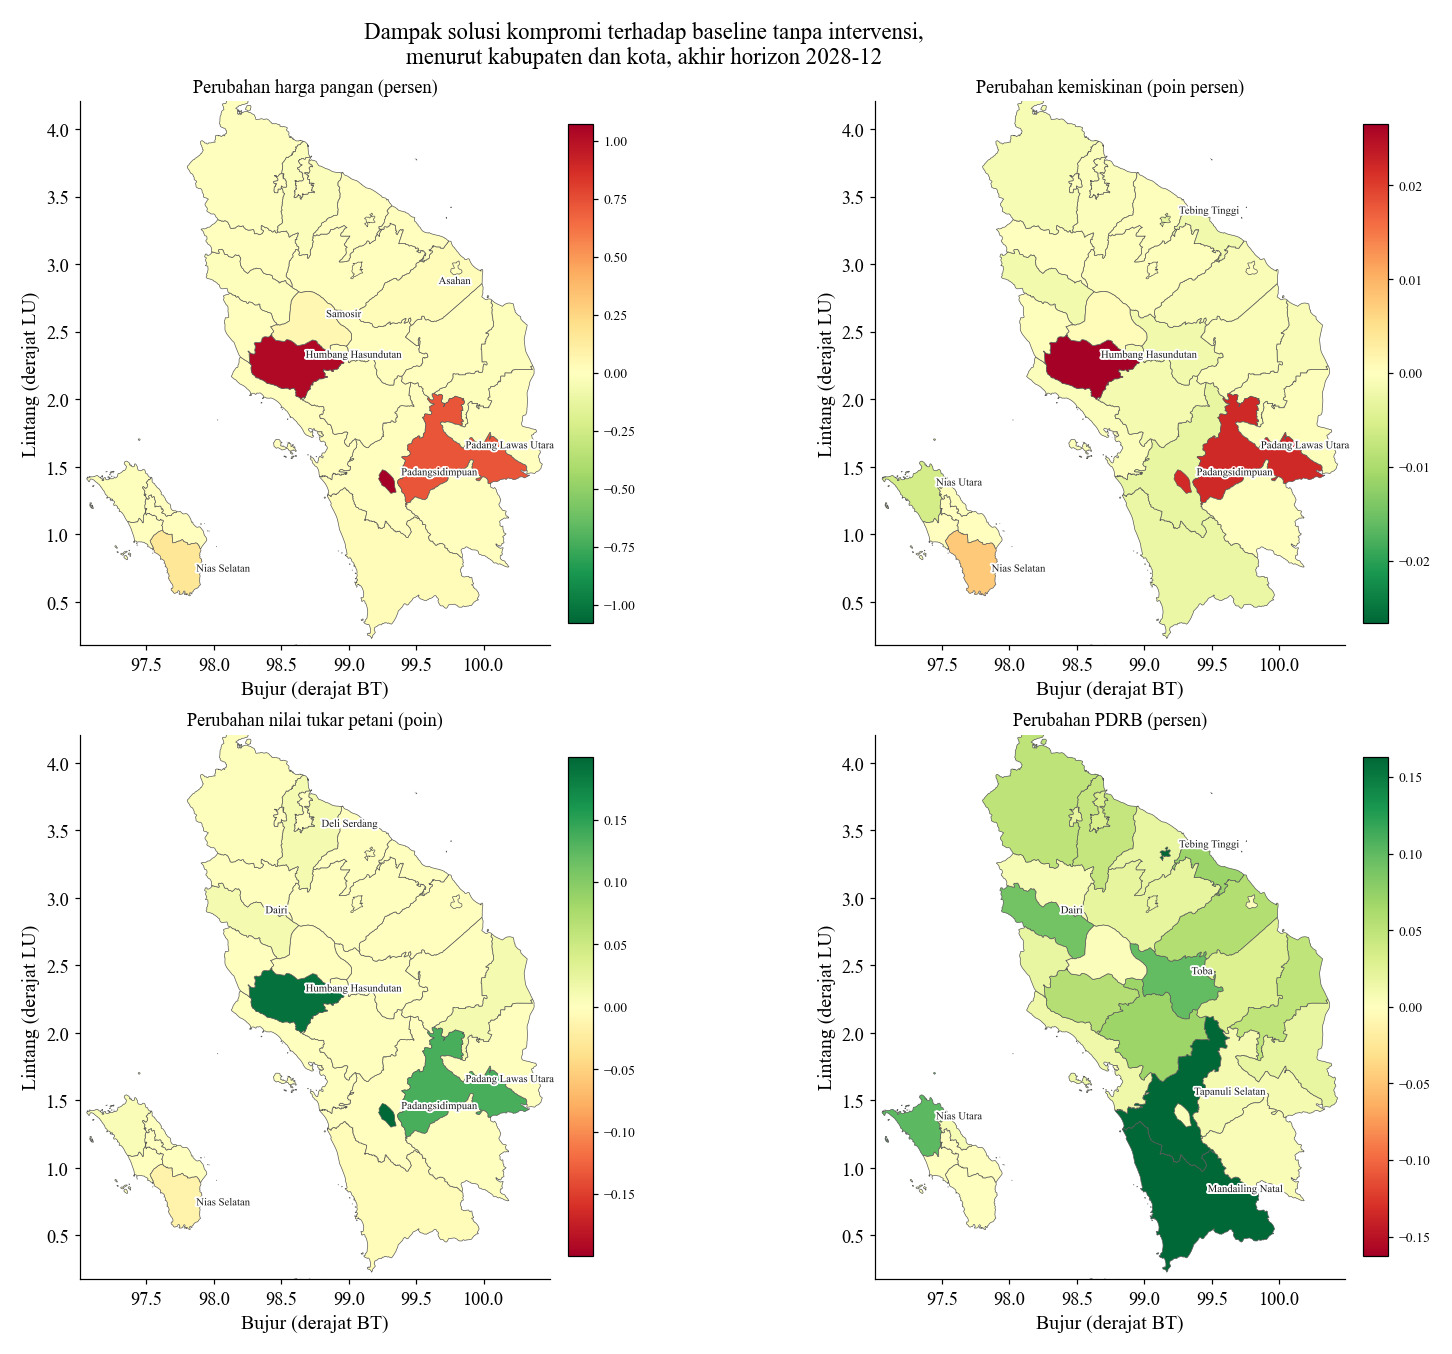

In [14]:
# Sel 7.1 - Dampak solusi kompromi menurut wilayah


def v6_muat_poligon():
    """Muat batas wilayah dari berkas GeoJSON bila tersedia.

    Pemadanan dilakukan lewat nama wilayah, bukan lewat kode, sebab berkas batas
    umumnya memakai kode Kemendagri berformat 12.NN sedangkan data statistik memakai
    kode BPS berformat 12NN, dan keduanya berbeda pada dua puluh dari tiga puluh tiga
    wilayah di Sumatera Utara.
    """
    calon = []
    for v6_b in [DIR_NB01.parent, DIR_NB01.parent.parent, Path.cwd()]:
        for v6_pola in ["*batas*kab*.geojson", "*kabupaten*.geojson", "*sumut*.geojson",
                        "*adm2*.geojson", "*sumatera*utara*.geojson"]:
            calon += [x for x in v6_b.rglob(v6_pola) if x.is_file()]
    if not calon:
        return None
    v6_jalur = sorted(set(calon), key=lambda x: -x.stat().st_size)[0]
    with open(v6_jalur, encoding="utf-8") as v6_f:
        v6_g = json.load(v6_f)

    def v6_baku(t):
        s = re.sub(r"^(kabupaten|kab\.|kab|kota)\s+", "", str(t).lower().strip())
        s = re.sub(r"[^a-z0-9]+", "", s)
        return {"padangsidempuan": "padangsidimpuan", "tobasamosir": "toba"}.get(s, s)

    v6_peta = {v6_baku(r.nama_baku): str(r.kode_wilayah) for r in REGISTRI.itertuples()}
    v6_keluar = {}
    for v6_ft in v6_g.get("features", []):
        v6_pr = v6_ft.get("properties", {})
        v6_nm = v6_pr.get("kab_kota") or v6_pr.get("NAMA") or v6_pr.get("name") or ""
        v6_kd = v6_peta.get(v6_baku(v6_nm))
        if v6_kd is None:
            continue
        v6_geom = v6_ft.get("geometry") or {}
        v6_polys = (v6_geom.get("coordinates", []) if v6_geom.get("type") == "MultiPolygon"
                    else [v6_geom.get("coordinates", [])])
        v6_ring = []
        for v6_p in v6_polys:
            if not v6_p:
                continue
            v6_r = np.asarray(v6_p[0], float)[:, :2]
            if len(v6_r) > 12:
                v6_simpan = [0]
                for v6_q in range(1, len(v6_r)):
                    if (abs(v6_r[v6_q, 0] - v6_r[v6_simpan[-1], 0]) > 0.004
                            or abs(v6_r[v6_q, 1] - v6_r[v6_simpan[-1], 1]) > 0.004):
                        v6_simpan.append(v6_q)
                if len(v6_simpan) >= 4:
                    v6_r = v6_r[v6_simpan]
            if len(v6_r) >= 4:
                v6_ring.append(v6_r)
        if v6_ring:
            v6_keluar[v6_kd] = v6_ring
    return v6_keluar


V6_POLIGON = v6_muat_poligon()


def v6_peta_tematik(ax, nilai_kode, cmap="RdYlGn_r"):
    from matplotlib.patches import Polygon as PoliMPL
    from matplotlib.collections import PatchCollection
    from matplotlib import colors as mcolors
    v6_v = np.array([nilai_kode.get(k, np.nan) for k in KODE], float)
    v6_m = max(abs(np.nanmin(v6_v)), abs(np.nanmax(v6_v)), 1e-12)
    v6_norma = mcolors.Normalize(vmin=-v6_m, vmax=v6_m)
    v6_pw = plt.get_cmap(cmap)
    if V6_POLIGON:
        v6_tampal, v6_warna = [], []
        for v6_idx, v6_k in enumerate(KODE):
            for v6_r in V6_POLIGON.get(v6_k, []):
                v6_tampal.append(PoliMPL(v6_r, closed=True))
                v6_warna.append(v6_pw(v6_norma(v6_v[v6_idx]))
                                if np.isfinite(v6_v[v6_idx]) else "0.90")
        ax.add_collection(PatchCollection(v6_tampal, facecolors=v6_warna,
                                          edgecolors="0.35", linewidths=0.45, zorder=2))
        ax.set_xlim(BUJUR.min() - 0.35, BUJUR.max() + 0.35)
        ax.set_ylim(LINTANG.min() - 0.5, LINTANG.max() + 0.5)
    else:
        ax.scatter(BUJUR, LINTANG, c=v6_v, cmap=v6_pw, norm=v6_norma, s=180,
                   edgecolors="0.3", linewidths=0.6, zorder=3)
        ax.margins(0.16)
    ax.set_aspect(1.0 / np.cos(np.radians(float(np.nanmean(LINTANG)))))
    ax.grid(False)
    ax.set_xlabel("Bujur (derajat BT)")
    ax.set_ylabel("Lintang (derajat LU)")
    return plt.cm.ScalarMappable(cmap=v6_pw, norm=v6_norma)


V6_R_KOMP = jalankan_kebijakan(V6_X_KOMPROMI[V6_SET_UTAMA])
V6_RING_KOMP = v6_ringkas(V6_R_KOMP)
v6_W_komp = blok_kesejahteraan(V6_R_KOMP)
v6_W_dasar = blok_kesejahteraan(V6_R_DASAR)

v6_d_harga = 100 * (V6_R_KOMP["ihp"][-1] / V6_R_DASAR["ihp"][-1] - 1)
v6_d_miskin = V6_R_KOMP["p0"][-1] - V6_R_DASAR["p0"][-1]
v6_d_ntp = v6_W_komp["NTP"][-1] - v6_W_dasar["NTP"][-1]
v6_d_pdrb = 100 * (V6_R_KOMP["y"][-1] / V6_R_DASAR["y"][-1] - 1)

DAMPAK_WIL_V6 = pd.DataFrame({
    "kode_wilayah": KODE,
    "wilayah": [NAMA[k] for k in KODE],
    "delta_harga_pangan_persen": v6_d_harga,
    "delta_kemiskinan_poin": v6_d_miskin,
    "delta_ntp_poin": v6_d_ntp,
    "delta_pdrb_persen": v6_d_pdrb,
    "penduduk_awal": POP0,
    "penduduk_akhir": V6_R_KOMP["pop"][-1],
    "jiwa_terhindar_miskin": -(v6_d_miskin / 100.0) * V6_R_KOMP["pop"][-1]})
simpan(DAMPAK_WIL_V6, "tabel/dampak_kompromi_per_wilayah_v6.csv")

v6_bobot = V6_R_KOMP["pop"][-1]
v6_agregat_level = 100.0 * (
    float(np.average(V6_R_KOMP["ihp"][-1], weights=v6_bobot))
    / float(np.average(V6_R_DASAR["ihp"][-1], weights=v6_bobot)) - 1.0)
v6_tujuan1_komp = v6_t_level_harga(V6_RING_KOMP, V6_DASAR)

print("=" * 78)
print("DAMPAK SOLUSI KOMPROMI MENURUT KABUPATEN DAN KOTA, himpunan", V6_SET_UTAMA)
print("=" * 78)
print("  poligon batas wilayah:",
      ("tersedia untuk " + str(len(V6_POLIGON)) + " wilayah") if V6_POLIGON
      else "tidak ditemukan, peta memakai titik sentroid")
print()
print("  nilai tujuan pertama solusi kompromi        :",
      format(v6_tujuan1_komp, "+.6f"), "persen")
print("  rata rata tertimbang penduduk atas level    :",
      format(v6_agregat_level, "+.6f"), "persen")
print("  selisih                                     :",
      format(abs(v6_tujuan1_komp - v6_agregat_level), ".3e"), "->",
      "KONSISTEN" if abs(v6_tujuan1_komp - v6_agregat_level) < 1e-10 else "TIDAK")
if abs(v6_tujuan1_komp - v6_agregat_level) >= 1e-10:
    raise RuntimeError("Nilai agregat tidak konsisten dengan tabel per wilayah.")
print()
print("  wilayah dengan kemiskinan turun:",
      int((DAMPAK_WIL_V6.delta_kemiskinan_poin < 0).sum()), "| naik:",
      int((DAMPAK_WIL_V6.delta_kemiskinan_poin > 0).sum()))
print("  jiwa terhindar dari kemiskinan, bersih seluruh provinsi:",
      format(float(DAMPAK_WIL_V6.jiwa_terhindar_miskin.sum()), ",.1f"), "jiwa")
print("  wilayah dengan harga pangan akhir turun:",
      int((DAMPAK_WIL_V6.delta_harga_pangan_persen < 0).sum()), "| naik:",
      int((DAMPAK_WIL_V6.delta_harga_pangan_persen > 0).sum()))
print()
v6_lima_baik = DAMPAK_WIL_V6.nlargest(5, "jiwa_terhindar_miskin")
v6_lima_buruk = DAMPAK_WIL_V6.nsmallest(5, "jiwa_terhindar_miskin")
print("  lima wilayah dengan tambahan jiwa terhindar terbanyak:")
for v6_rec in v6_lima_baik.itertuples():
    print("    " + v6_rec.wilayah.ljust(24),
          format(v6_rec.jiwa_terhindar_miskin, "10.1f"), "jiwa")
print("  lima wilayah dengan kemiskinan naik terbanyak:")
for v6_rec in v6_lima_buruk.itertuples():
    print("    " + v6_rec.wilayah.ljust(24),
          format(v6_rec.jiwa_terhindar_miskin, "10.1f"), "jiwa")

fig, sb = plt.subplots(2, 2, figsize=(14.4, 12.0))
for v6_ax, v6_v, v6_jud, v6_cm in [
        (sb[0, 0], v6_d_harga, "Perubahan harga pangan (persen)", "RdYlGn_r"),
        (sb[0, 1], v6_d_miskin, "Perubahan kemiskinan (poin persen)", "RdYlGn_r"),
        (sb[1, 0], v6_d_ntp, "Perubahan nilai tukar petani (poin)", "RdYlGn"),
        (sb[1, 1], v6_d_pdrb, "Perubahan PDRB (persen)", "RdYlGn")]:
    v6_sm = v6_peta_tematik(v6_ax, dict(zip(KODE, v6_v)), cmap=v6_cm)
    v6_ax.set_title(v6_jud, fontsize=UKURAN - 1)
    v6_cb = fig.colorbar(v6_sm, ax=v6_ax, fraction=0.036, pad=0.02)
    v6_cb.ax.tick_params(labelsize=UKURAN - 4)
    v6_ekstrem = np.argsort(-np.abs(v6_v))[:6]
    label_tanpa_tumpang(v6_ax, BUJUR[v6_ekstrem], LINTANG[v6_ekstrem],
                        [NAMA[KODE[i]] for i in v6_ekstrem], fontsize=UKURAN - 6)
fig.suptitle("Dampak solusi kompromi terhadap baseline tanpa intervensi,\n"
             "menurut kabupaten dan kota, akhir horizon " + str(BULAN_DEPAN[-1]))
simpan_gambar(fig, "gambar_03_peta_dampak_kompromi_v6",
              "Peta dampak solusi kompromi pada empat besaran menurut wilayah")
plt.show()

# Bagian 8. Gambar Hasil Optimisasi

## 8.1 Pareto front dalam parallel coordinates

*Parallel coordinates* (koordinat sejajar) menampilkan setiap kebijakan sebagai satu
garis yang memotong seluruh sumbu tujuan. Setiap sumbu diskalakan sendiri sendiri dan
digambar dengan arah alami, yaitu makin ke bawah makin baik, sehingga garis yang datar
rendah pada seluruh sumbu adalah kebijakan yang baik pada seluruh tujuan sekaligus dan
garis yang menyilang tajam menandakan adanya pertukaran.

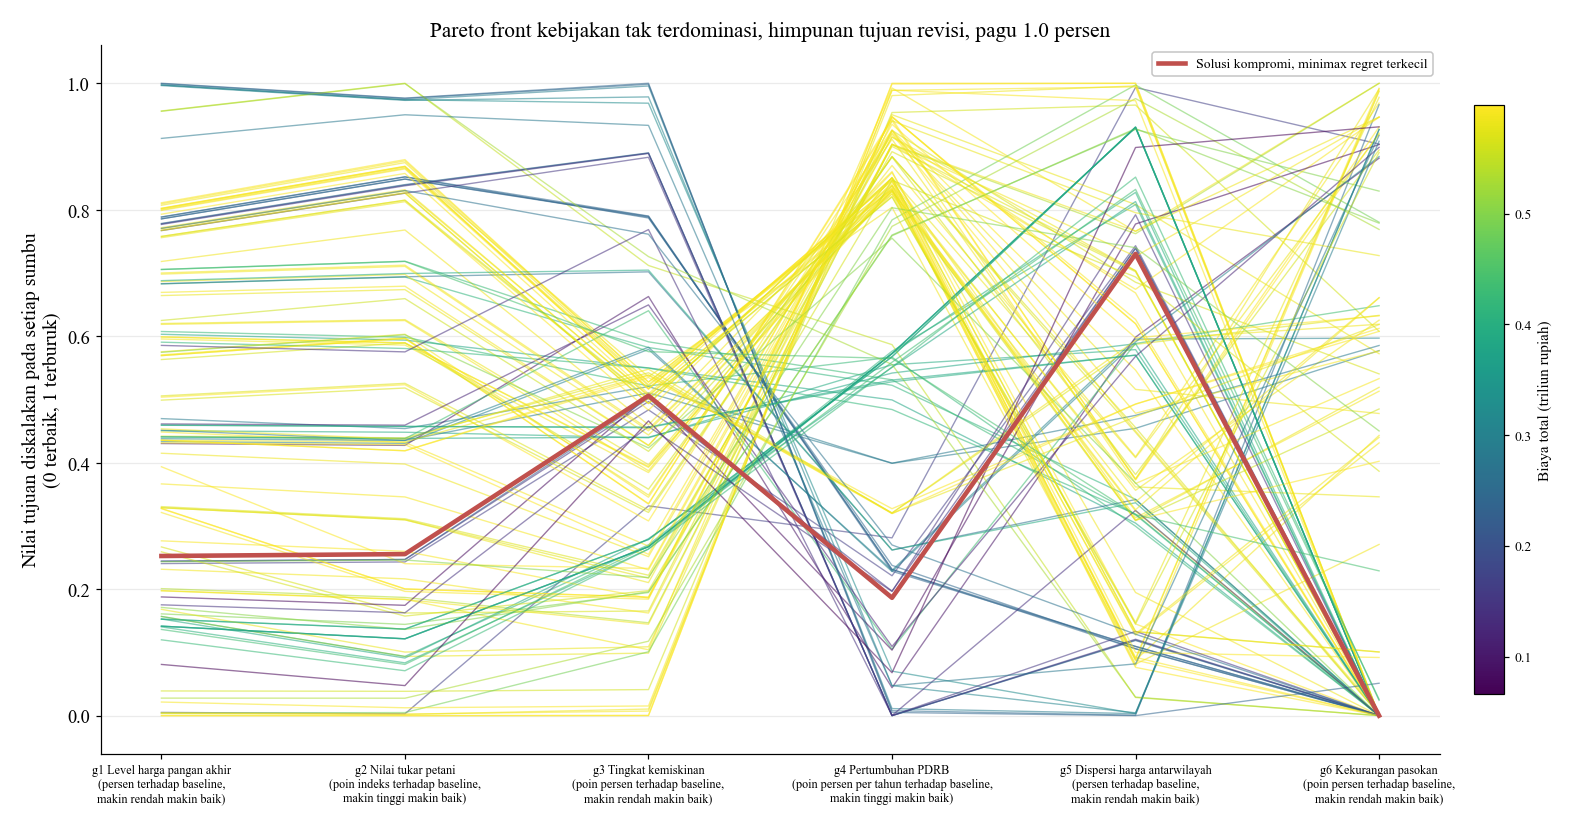

Gambar 4 disimpan. Jumlah kebijakan tak terdominasi: 128
Nilai batas setiap sumbu, dalam arah alami:
  g1 Level harga pangan akhir          terbaik    0.00047 | terburuk    0.17708
  g2 Nilai tukar petani                terbaik    0.00006 | terburuk    0.03835
  g3 Tingkat kemiskinan                terbaik   -0.00446 | terburuk    0.00530
  g4 Pertumbuhan PDRB                  terbaik    0.00000 | terburuk    0.07508
  g5 Dispersi harga antarwilayah       terbaik  -28.92905 | terburuk   -0.09801
  g6 Kekurangan pasokan                terbaik   -0.87971 | terburuk    0.00014


In [15]:
# Sel 8.1 - Gambar 4: Pareto front dalam parallel coordinates

v6_set = V6_SET_UTAMA
v6_kode = V6_KODE_TUJUAN[v6_set]
v6_front = PARETO_UTAMA_V6
v6_M = v6_front[v6_kode].to_numpy(float) * V6_TANDA_TAMPIL[v6_set][None, :]
v6_lo = v6_M.min(axis=0)
v6_hi = v6_M.max(axis=0)
v6_N = (v6_M - v6_lo) / np.maximum(v6_hi - v6_lo, 1e-12)

v6_ikom = int(V6_KOMPROMI[v6_set]["indeks_pareto"])
v6_warna_biaya = v6_front["biaya_total_triliun"].to_numpy(float)

fig, ax = plt.subplots(figsize=(14.0, 7.2))
v6_norma = plt.Normalize(v6_warna_biaya.min(), v6_warna_biaya.max())
v6_pw = plt.get_cmap("viridis")
for v6_i in range(len(v6_N)):
    ax.plot(np.arange(V6_NM), v6_N[v6_i], color=v6_pw(v6_norma(v6_warna_biaya[v6_i])),
            linewidth=0.9, alpha=0.55, zorder=2)
if 0 <= v6_ikom < len(v6_N):
    ax.plot(np.arange(V6_NM), v6_N[v6_ikom], color=PALET[1], linewidth=3.0,
            zorder=5, label="Solusi kompromi, minimax regret terkecil")
ax.set_xticks(np.arange(V6_NM))
ax.set_xticklabels(V6_LABEL_TUJUAN[v6_set], fontsize=UKURAN - 5)
ax.set_ylabel("Nilai tujuan diskalakan pada setiap sumbu\n(0 terbaik, 1 terburuk)")
ax.set_ylim(-0.06, 1.06)
ax.set_title("Pareto front kebijakan tak terdominasi, himpunan tujuan "
             + v6_set + ", pagu " + format(PANGSA_PAGU[1] * 100, ".1f") + " persen")
ax.legend(loc="upper right", fontsize=UKURAN - 4)
v6_sm = plt.cm.ScalarMappable(cmap=v6_pw, norm=v6_norma)
v6_cb = fig.colorbar(v6_sm, ax=ax, fraction=0.022, pad=0.015)
v6_cb.set_label("Biaya total (triliun rupiah)", fontsize=UKURAN - 3)
v6_cb.ax.tick_params(labelsize=UKURAN - 4)
ax.grid(axis="x", visible=False)
simpan_gambar(fig, "gambar_04_pareto_front_v6",
              "Pareto front kebijakan tak terdominasi pada himpunan tujuan revisi")
plt.show()

print("Gambar 4 disimpan. Jumlah kebijakan tak terdominasi:", len(v6_front))
print("Nilai batas setiap sumbu, dalam arah alami:")
for v6_j, v6_nm in enumerate(V6_NAMA_TUJUAN[v6_set]):
    print("  " + v6_nm.ljust(36), "terbaik", format(v6_lo[v6_j], "10.5f"),
          "| terburuk", format(v6_hi[v6_j], "10.5f"))

## 8.2 Selang persentil pada penarikan parameter

Gambar berikut menampilkan selang persentil sepuluh sampai sembilan puluh setiap tujuan
untuk seluruh kebijakan yang diuji ulang pada penarikan parameter. Kebijakan diurutkan
menurut *minimax regret*, dari yang paling tegar di kiri. Selang yang seluruhnya berada
di satu sisi garis nol menandakan arah pengaruh yang tetap pada seluruh keadaan dunia
yang diuji, dan itulah satu satunya bentuk klaim yang layak dikutip untuk tujuan yang
tidak *discriminable*.

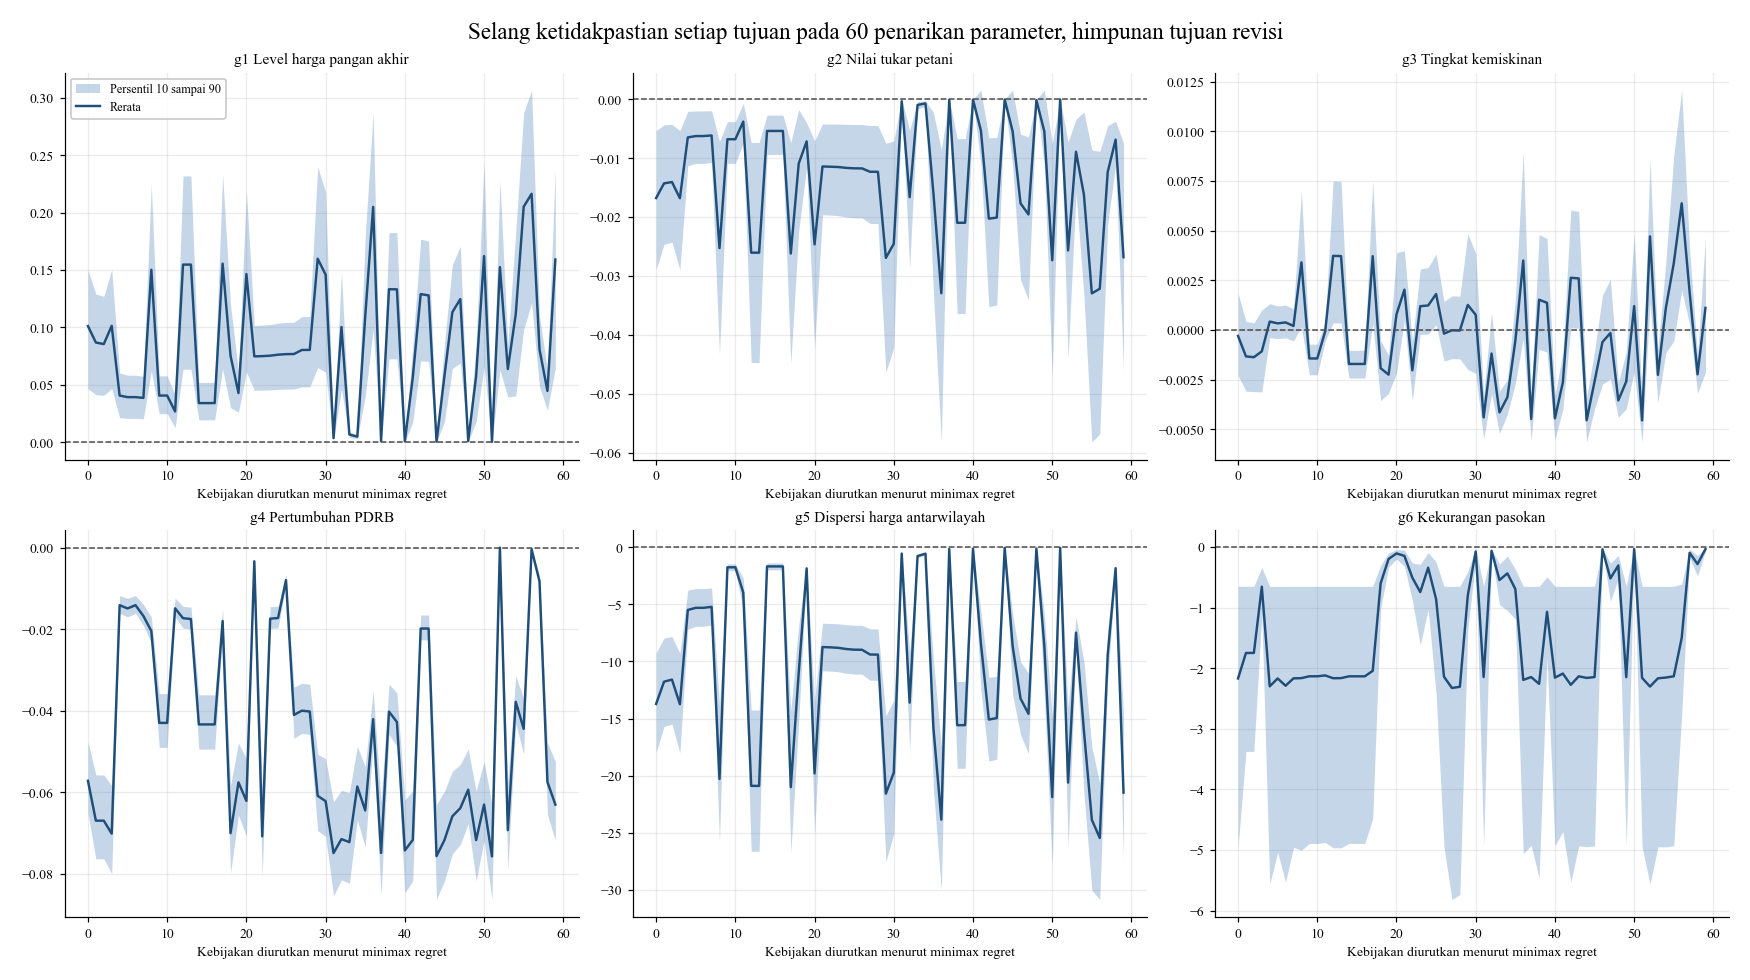

Gambar 5 disimpan.
  tujuan                                arah tetap   menang pada
  g1 Level harga pangan akhir                   ya          0.0%
  g2 Nilai tukar petani                      tidak         96.7%
  g3 Tingkat kemiskinan                      tidak         31.7%
  g4 Pertumbuhan PDRB                        tidak        100.0%
  g5 Dispersi harga antarwilayah                ya        100.0%
  g6 Kekurangan pasokan                         ya        100.0%


In [16]:
# Sel 8.2 - Gambar 5: selang persentil setiap tujuan

v6_set = V6_SET_UTAMA
v6_tg = V6_TEGAR[v6_set].sort_values("minimax_regret").reset_index(drop=True)
v6_kode = V6_KODE_TUJUAN[v6_set]

fig, sb = plt.subplots(2, 3, figsize=(15.6, 8.6))
for v6_j, v6_ax in enumerate(sb.ravel()):
    v6_c = v6_kode[v6_j]
    v6_x = np.arange(len(v6_tg))
    v6_p10 = v6_tg[v6_c + "_p10"].to_numpy(float)
    v6_p90 = v6_tg[v6_c + "_p90"].to_numpy(float)
    v6_rt = v6_tg[v6_c + "_rerata"].to_numpy(float)
    v6_ax.fill_between(v6_x, v6_p10, v6_p90, color=PALET[2], alpha=0.32,
                       linewidth=0, label="Persentil 10 sampai 90")
    v6_ax.plot(v6_x, v6_rt, color=PALET[0], linewidth=1.6, label="Rerata")
    v6_ax.axhline(0.0, color="0.30", linewidth=1.0, linestyle="--")
    v6_ax.set_title(V6_NAMA_TUJUAN[v6_set][v6_j], fontsize=UKURAN - 3)
    v6_ax.set_xlabel("Kebijakan diurutkan menurut minimax regret",
                     fontsize=UKURAN - 4)
    v6_ax.tick_params(labelsize=UKURAN - 4)
    if v6_j == 0:
        v6_ax.legend(fontsize=UKURAN - 5, loc="best")
fig.suptitle("Selang ketidakpastian setiap tujuan pada " + str(N_DRAW)
             + " penarikan parameter, himpunan tujuan " + v6_set)
simpan_gambar(fig, "gambar_05_robustness_v6",
              "Selang persentil sepuluh sampai sembilan puluh setiap tujuan")
plt.show()

print("Gambar 5 disimpan.")
print("  " + "tujuan".ljust(36) + "arah tetap".rjust(12) + "menang pada".rjust(14))
for v6_j, v6_nm in enumerate(V6_NAMA_TUJUAN[v6_set]):
    v6_c = v6_kode[v6_j]
    v6_tetap = bool(np.all(v6_tg[v6_c + "_p10"] > 0) or np.all(v6_tg[v6_c + "_p90"] < 0))
    print("  " + v6_nm.ljust(36) + ("ya" if v6_tetap else "tidak").rjust(12)
          + format(100 * float(V6_KOMPROMI[v6_set][v6_c + "_menang"]), "13.1f") + "%")

# Bagian 9. Ringkasan Naratif Otomatis dan Manifes Keluaran

Ringkasan pada sel berikut disusun seluruhnya dari nilai yang sudah dihitung pada
sel sebelumnya. Tidak ada kalimat yang berisi angka yang tidak berasal dari tabel atau
peubah hasil perhitungan, dan tidak ada penilaian yang tidak dapat ditelusuri kembali ke
satu perbandingan angka yang eksplisit.

In [17]:
# Sel 9.1 - Ringkasan naratif otomatis

v6_set = V6_SET_UTAMA
v6_kom = V6_KOMPROMI[v6_set]
v6_kode = V6_KODE_TUJUAN[v6_set]
v6_dg = V6_DIAG[v6_set]
v6_baris = []


def v6_tulis(teks=""):
    v6_baris.append(teks)


v6_tulis("=" * 78)
v6_tulis("RINGKASAN NOTEBOOK 06")
v6_tulis("=" * 78)
v6_tulis()
v6_tulis("1. Kesetaraan mesin.")
if V6_SETARA is None:
    v6_tulis("   Berkas pembanding Notebook 05 tidak ditemukan sehingga kesetaraan")
    v6_tulis("   mesin tidak dapat diperiksa pada penjalanan ini.")
else:
    v6_tulis("   Mesin simulasi yang dimuat ulang identik dengan Notebook 05 dengan")
    v6_tulis("   deviasi relatif terbesar " + format(V6_DEV_MAKS_NB05, ".3e")
             + " pada sembilan besaran ringkas.")
v6_tulis()
v6_tulis("2. Cacat pada objective function f1 Notebook 05.")
v6_tulis("   Identitas penguraian terbukti dengan galat terbesar "
         + format(V6_GALAT_IDENTITAS, ".3e") + " poin persen.")
v6_gagal = DEKOMPOSISI_F1[(DEKOMPOSISI_F1.f1_lama_poin_persen < -1e-6)
                          & (DEKOMPOSISI_F1.pengaruh_level_akhir_persen > 1e-6)]
v6_tulis("   Dari " + str(len(DEKOMPOSISI_F1)) + " kebijakan uji, " + str(len(v6_gagal))
         + " kebijakan menunjukkan f1 lama bertanda negatif")
v6_tulis("   sementara level harga pangan akhirnya justru naik.")
if len(v6_gagal):
    v6_wk = v6_gagal.loc[v6_gagal.f1_lama_poin_persen.idxmin()]
    v6_tulis("   Contoh terjauh adalah " + str(v6_wk["kebijakan"]) + " dengan f1 lama "
             + format(float(v6_wk.f1_lama_poin_persen), "+.4f") + " poin persen,")
    v6_tulis("   level harga akhir " + format(float(v6_wk.pengaruh_level_akhir_persen),
                                              "+.4f")
             + " persen, dan pergeseran periode dasar "
             + format(float(v6_wk.pergeseran_periode_dasar_persen), "+.4f") + " persen.")
v6_tulis()
v6_tulis("3. Screening tuas kebijakan.")
v6_n_mati = int((~V6_HUBUNG.to_numpy()).sum())
v6_tulis("   Dari " + str(int(V6_HUBUNG.size)) + " pasangan tuas dan besaran, "
         + str(v6_n_mati) + " pasangan bernilai nol persis,")
v6_tulis("   yang berarti jalur sebab akibatnya memang tidak ada di dalam model.")
for v6_kol, v6_label, _ in V6_BESARAN:
    v6_hidup = [SCREENING_TUAS.loc[v6_i, "tuas"] for v6_i in range(len(SCREENING_TUAS))
                if abs(float(SCREENING_TUAS.loc[v6_i, v6_kol])) > V6_AMBANG_NOL]
    v6_tulis("   " + v6_label + ": "
             + (", ".join(v6_hidup) if v6_hidup else "tidak digerakkan tuas mana pun"))
v6_tulis()
v6_tulis("4. Pareto front setelah koreksi, himpunan " + v6_set + ".")
v6_tulis("   Jumlah kebijakan tak terdominasi " + str(len(PARETO_UTAMA_V6))
         + " pada pagu " + format(PAGU_UTAMA / 1e12, ".3f") + " triliun rupiah.")
for v6_j, v6_nm in enumerate(V6_NAMA_TUJUAN[v6_set]):
    v6_c = v6_kode[v6_j]
    v6_tulis("   " + v6_nm.ljust(34) + "rentang "
             + format(float(PARETO_UTAMA_V6[v6_c].min()), "10.5f") + " sampai "
             + format(float(PARETO_UTAMA_V6[v6_c].max()), "10.5f"))
v6_menyesatkan = int(((PARETO_UTAMA_V6[v6_kode[0]] > 0)
                      & (PARETO_UTAMA_V6["f1_lama_setara_poin_persen"] < 0)).sum())
v6_tulis("   Jumlah titik yang pada definisi lama tampak menurunkan harga padahal level")
v6_tulis("   harga akhirnya naik: " + str(v6_menyesatkan) + " dari "
         + str(len(PARETO_UTAMA_V6)) + " titik.")
v6_tulis()
v6_tulis("5. Solusi kompromi menurut minimax regret.")
for v6_k in KODE_X:
    v6_d = next(r for r in RUANG_KEBIJAKAN if r["kode"] == v6_k)
    v6_tulis("   " + v6_d["nama"].ljust(36) + format(float(v6_kom[v6_k]), "8.3f") + "  "
             + v6_d["satuan"])
v6_tulis("   Biaya rerata " + format(float(v6_kom.biaya_rerata_triliun), ".3f")
         + " triliun rupiah, layak pada "
         + format(100 * float(v6_kom.pangsa_layak), ".0f") + " persen penarikan,")
v6_tulis("   dengan minimax regret " + format(float(v6_kom.minimax_regret), ".4f") + ".")
for v6_j, v6_nm in enumerate(V6_NAMA_TUJUAN[v6_set]):
    v6_c = v6_kode[v6_j]
    v6_tulis("   " + v6_nm.ljust(34) + "rerata "
             + format(float(v6_kom[v6_c + "_rerata"]), "+10.5f") + " | menang pada "
             + format(100 * float(v6_kom[v6_c + "_menang"]), "5.1f") + " persen penarikan")
v6_tulis()
v6_tulis("6. Keterbedaan dan redundansi.")
v6_beda = v6_dg[v6_dg.discriminable]["kode"].tolist()
v6_takbeda = v6_dg[~v6_dg.discriminable]["kode"].tolist()
v6_tulis("   Tujuan discriminable: " + (", ".join(v6_beda) if v6_beda else "tidak ada"))
v6_tulis("   Tujuan tidak discriminable: "
         + (", ".join(v6_takbeda) if v6_takbeda else "tidak ada"))
v6_pas = (REDUNDANSI_V6[REDUNDANSI_V6.himpunan == v6_set] if len(REDUNDANSI_V6)
          else REDUNDANSI_V6)
if len(v6_pas) == 0:
    v6_tulis("   Tidak ada pasangan tujuan yang redundan pada ambang korelasi peringkat "
             + str(V6_AMBANG_REDUNDAN) + ".")
else:
    for v6_rec in v6_pas.itertuples():
        v6_tulis("   Redundan: " + v6_rec.tujuan_a + " dan " + v6_rec.tujuan_b
                 + ", rho " + format(v6_rec.rho_spearman, ".6f"))
v6_tulis()
v6_tulis("7. Dampak menurut wilayah pada solusi kompromi.")
v6_tulis("   Kemiskinan turun di "
         + str(int((DAMPAK_WIL_V6.delta_kemiskinan_poin < 0).sum())) + " wilayah dan naik di "
         + str(int((DAMPAK_WIL_V6.delta_kemiskinan_poin > 0).sum())) + " wilayah,")
v6_tulis("   dengan hasil bersih "
         + format(float(DAMPAK_WIL_V6.jiwa_terhindar_miskin.sum()), ",.1f")
         + " jiwa terhindar dari kemiskinan.")
v6_tulis("   Harga pangan akhir turun di "
         + str(int((DAMPAK_WIL_V6.delta_harga_pangan_persen < 0).sum()))
         + " wilayah dan naik di "
         + str(int((DAMPAK_WIL_V6.delta_harga_pangan_persen > 0).sum())) + " wilayah.")
v6_tulis()
v6_tulis("8. Apa yang boleh dan tidak boleh dikutip dari penjalanan ini.")
v6_tulis("   Boleh dikutip: peringkat antarkebijakan pada tujuan yang discriminable,")
v6_tulis("   arah pengaruh pada tujuan yang selang persentilnya tidak memuat nol, serta")
v6_tulis("   pernyataan bahwa suatu tuas tidak menyentuh suatu besaran sama sekali.")
v6_tulis("   Tidak boleh dikutip: peringkat pada tujuan yang tidak discriminable,")
v6_tulis("   pertukaran antara dua tujuan yang terbukti redundan, dan tingkat mutlak")
v6_tulis("   pertumbuhan PDRB, sebab koreksi kondisi awal stok modal pada Notebook 05")
v6_tulis("   membuat tingkat pertumbuhan tidak lagi setara pengamatan sehingga hanya")
v6_tulis("   selisihnya terhadap baseline yang bermakna.")

RINGKASAN_V6 = "\n".join(v6_baris)
simpan_teks(RINGKASAN_V6, "log/ringkasan_otomatis_nb06.txt")
print(RINGKASAN_V6)

RINGKASAN NOTEBOOK 06

1. Kesetaraan mesin.
   Mesin simulasi yang dimuat ulang identik dengan Notebook 05 dengan
   deviasi relatif terbesar 2.549e-15 pada sembilan besaran ringkas.

2. Cacat pada objective function f1 Notebook 05.
   Identitas penguraian terbukti dengan galat terbesar 1.998e-14 poin persen.
   Dari 9 kebijakan uji, 5 kebijakan menunjukkan f1 lama bertanda negatif
   sementara level harga pangan akhirnya justru naik.
   Contoh terjauh adalah Subsidi angkutan penuh dengan f1 lama -4.8936 poin persen,
   level harga akhir +0.3660 persen, dan pergeseran periode dasar +3.7735 persen.

3. Screening tuas kebijakan.
   Dari 32 pasangan tuas dan besaran, 19 pasangan bernilai nol persis,
   yang berarti jalur sebab akibatnya memang tidak ada di dalam model.
   Level harga pangan akhir: Subsidi angkutan
   Dispersi harga antarwilayah: Subsidi angkutan
   Kekurangan pasokan: Subsidi angkutan, Cadangan dan operasi pasar, Dukungan produksi, Insentif investasi
   Nilai tukar petani

## 9.2 Manifes keluaran dan tambalan untuk Notebook 05

Sel penutup menuliskan daftar seluruh berkas yang dihasilkan, beserta satu berkas teks
berisi potongan kode pengganti untuk Notebook 05. Potongan itu dapat ditempelkan ke
Notebook 05 apabila keseluruhan Notebook 05 hendak dijalankan ulang dengan definisi
tujuan yang sudah benar, misalnya untuk membangun ulang berkas dashboard HTML yang
memang dihasilkan di sana.

In [18]:
# Sel 9.2 - Manifes keluaran dan potongan tambalan untuk Notebook 05

V6_TAMBALAN = "\n".join([
    "Tambalan untuk Notebook 05.",
    "",
    "Langkah 1. Pada Sel 3.4, di dalam fungsi ringkas_hasil, ganti perhitungan naik",
    "dengan tiga baris berikut:",
    "",
    "    lv_awal = float(np.average(R['ihp'][0], weights=b0))",
    "    lv_akhir = float(np.average(R['ihp'][-1], weights=b1))",
    "    naik = 100 * (lv_akhir / lv_awal - 1)",
    "",
    "lalu tambahkan dua kunci pada kamus yang dikembalikan:",
    "",
    "    'level_harga_awal': lv_awal,",
    "    'level_harga_akhir': lv_akhir,",
    "",
    "Langkah 2. Pada Sel 6.1, di dalam fungsi tujuan_satu, ganti baris",
    "",
    "    r['kenaikan_harga_pangan_persen'] - ref['kenaikan_harga_pangan_persen'],",
    "",
    "menjadi",
    "",
    "    100.0 * (r['level_harga_akhir'] / ref['level_harga_akhir'] - 1.0),",
    "",
    "Langkah 3. Lakukan penggantian yang sama pada fungsi vektor_tujuan di Sel 7.1.",
    "",
    "Langkah 4. Pada daftar TUJUAN di Sel 6.1, ubah nama dan satuan tujuan pertama",
    "menjadi Level harga pangan akhir dengan satuan persen terhadap baseline.",
    "",
    "Langkah 5. Jalankan ulang Notebook 05 dari Sel 3.4 sampai selesai. Dengan begitu",
    "berkas dashboard HTML yang dibangun pada Sel 9.2 ikut memakai definisi yang benar.",
    "",
    "Catatan. Notebook 06 tidak mengubah berkas Notebook 05 sama sekali. Tambalan ini",
    "hanya diperlukan apabila keluaran Notebook 05 sendiri hendak diperbarui.",
])

simpan_teks(V6_TAMBALAN, "log/tambalan_untuk_notebook05.txt")

v6_berkas = []
for v6_akar, _, v6_daftar in os.walk(DIR_KELUARAN):
    for v6_n in sorted(v6_daftar):
        v6_p = Path(v6_akar) / v6_n
        v6_berkas.append({
            "berkas": str(v6_p.relative_to(DIR_KELUARAN)),
            "ukuran_kb": round(v6_p.stat().st_size / 1024.0, 1)})
MANIFES_V6 = pd.DataFrame(v6_berkas).sort_values("berkas").reset_index(drop=True)
simpan(MANIFES_V6, "log/manifes_keluaran_nb06.csv")

print("=" * 78)
print("MANIFES KELUARAN NOTEBOOK 06")
print("=" * 78)
print("  folder keluaran:", DIR_KELUARAN)
if DIR_DRIVE is not None:
    print("  salinan Drive  :", DIR_DRIVE)
print("  jumlah berkas  :", len(MANIFES_V6))
print()
for v6_rec in MANIFES_V6.itertuples():
    print("  " + v6_rec.berkas.ljust(58) + format(v6_rec.ukuran_kb, "10.1f") + " KB")
print()
print("  Gambar yang dihasilkan:")
for v6_g in KATALOG_GAMBAR:
    print("    " + v6_g["berkas"].ljust(44) + v6_g["keterangan"])
print()
print("Notebook 06 selesai. Kompres folder", DIR_KELUARAN.name, "menjadi satu berkas ZIP")
print("lalu unggah kembali untuk penyusunan ulang naskah.")

MANIFES KELUARAN NOTEBOOK 06
  folder keluaran: /Users/user/Desktop/Proyek lomba paper/Sumatranomics/Output/Keluaran_Sumatranomics_2026_Sumut_NB06
  salinan Drive  : /Users/user/Library/CloudStorage/GoogleDrive-dgiveup719@gmail.com/My Drive/Sumatranomics_2026_Sumut/Notebook06_20260831
  jumlah berkas  : 24

  gambar/gambar_01_dekomposisi_f1.png                            195.7 KB
  gambar/gambar_02_keterhubungan_tuas.png                        361.4 KB
  gambar/gambar_03_peta_dampak_kompromi_v6.png                  1396.6 KB
  gambar/gambar_04_pareto_front_v6.png                          4054.1 KB
  gambar/gambar_05_robustness_v6.png                            1115.4 KB
  log/ringkasan_otomatis_nb06.txt                                  4.3 KB
  log/tambalan_untuk_notebook05.txt                                1.2 KB
  mutu/diagnostik_discriminability_v6.csv                          1.5 KB
  mutu/konvergensi_optimisasi_v6.csv                              12.1 KB
  mutu/korelasi_peringkat

# Daftar Pustaka

Deb, K., & Jain, H. (2014). An evolutionary many-objective optimization algorithm using
reference-point-based nondominated sorting approach, part I: Solving problems with box
constraints. *IEEE Transactions on Evolutionary Computation, 18*(4), 577-601.
https://doi.org/10.1109/TEVC.2013.2281535

Kwakkel, J. H. (2017). The Exploratory Modeling Workbench: An open source toolkit for
exploratory modeling, scenario discovery, and (multi-objective) robust decision making.
*Environmental Modelling & Software, 96*, 239-250.
https://doi.org/10.1016/j.envsoft.2017.06.054

Saltelli, A., & Annoni, P. (2010). How to avoid a perfunctory sensitivity analysis.
*Environmental Modelling & Software, 25*(12), 1508-1517.
https://doi.org/10.1016/j.envsoft.2010.04.012

Savage, L. J. (1951). The theory of statistical decision. *Journal of the American
Statistical Association, 46*(253), 55-67.
https://doi.org/10.1080/01621459.1951.10500768

Sterman, J. D. (2000). *Business dynamics: Systems thinking and modeling for a complex
world*. Irwin McGraw-Hill.